# Análisis Exploratorio de Datos (EDA)
## Dataset: Diabetes 130-US Hospitals (1999–2008)
### Analítica de Datos — Universidad de San Andrés
---
**Trabajo Práctico Integrador — Entrega 1**


## 0. Librerías e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE_TARGET = {'NO': '#4C9BE8', '>30': '#F4A261', '<30': '#E76F51'}


---
## 1. Carga y descripción del dataset

### 1.1 Origen y contexto

El dataset **"Diabetes 130-US Hospitals for Years 1999-2008"** fue compilado por Beata Strack et al. y publicado en el repositorio **UCI Machine Learning Repository** (ID 296). Contiene registros de encuentros hospitalarios de pacientes diabéticos provenientes de **130 hospitales** de Estados Unidos durante el período 1999–2008.

Los datos fueron extraídos de la base **Health Facts** (Cerner Corporation), una base de datos clínica nacional de EE. UU. Cada registro representa un **encuentro hospitalario** (*encounter*): una internación de un paciente diabético que cumple los siguientes criterios:
- Es un encuentro de tipo hospitalario (no ambulatorio).
- La duración de la estadía fue entre 1 y 14 días.
- Se realizaron pruebas de laboratorio durante el encuentro.
- Se administraron medicamentos durante el encuentro.

El dataset incluye información demográfica del paciente, diagnósticos, procedimientos, medicamentos administrados y el resultado de readmisión hospitalaria.

El paper de referencia es: *Strack, B., et al. (2014). "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records." BioMed Research International.*

### 1.2 Unidad de observación

Cada fila representa un **encuentro hospitalario** (no un paciente único). Un mismo paciente puede tener múltiples encuentros. Esto es relevante porque implica **dependencia entre observaciones**, que deberá ser considerada en el modelado.


In [2]:
# ── Carga del dataset principal y el mapeo de IDs ───────────────────────────
df = pd.read_csv('/content/diabetic_data.csv')
ids_map = pd.read_csv('/content/IDS_mapping.csv')

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
df.head(3)


Dataset cargado: 101,766 filas × 50 columnas

Primeras filas:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


---
## 2. Estructura general del dataset


In [3]:
# ── Dimensiones ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Número de observaciones (encuentros): {df.shape[0]:>10,}")
print(f"  Número de variables:                  {df.shape[1]:>10}")
print("=" * 55)


  Número de observaciones (encuentros):    101,766
  Número de variables:                          50


In [4]:
# ── Tipos de datos ───────────────────────────────────────────────────────────
# Columnas numéricas y categóricas
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"Variables numéricas ({len(num_cols)}):  {num_cols}")
print(f"\nVariables categóricas ({len(cat_cols)}): {cat_cols}")


Variables numéricas (13):  ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables categóricas (37): ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [5]:
# ── Tabla resumen de variables ───────────────────────────────────────────────
summary_rows = []
for col in df.columns:
    dtype = str(df[col].dtype)
    n_unique = df[col].nunique()
    missing_q = (df[col] == '?').sum() if df[col].dtype == object else 0
    sample_vals = df[col].dropna().unique()[:4]
    summary_rows.append({
        'Variable': col,
        'Tipo': 'Categórica' if df[col].dtype == object else 'Numérica',
        'dtype': dtype,
        'Únicos': n_unique,
        'Missing (?)': missing_q,
        '% Missing': f"{100*missing_q/len(df):.1f}%",
        'Ejemplo valores': str(list(sample_vals))
    })

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 60)
summary_df


,Variable,Tipo,dtype,Únicos,Missing (?),% Missing,Ejemplo valores
0,encounter_id,Numérica,int64,101766,0,0.0%,"[np.int64(2278392), np.int64(149190), np.int64(64410), n..."
1,patient_nbr,Numérica,int64,71518,0,0.0%,"[np.int64(8222157), np.int64(55629189), np.int64(8604787..."
2,race,Categórica,object,6,2273,2.2%,"['Caucasian', 'AfricanAmerican', '?', 'Other']"
3,gender,Categórica,object,3,0,0.0%,"['Female', 'Male', 'Unknown/Invalid']"
4,age,Categórica,object,10,0,0.0%,"['[0-10)', '[10-20)', '[20-30)', '[30-40)']"
5,weight,Categórica,object,10,98569,96.9%,"['?', '[75-100)', '[50-75)', '[0-25)']"
6,admission_type_id,Numérica,int64,8,0,0.0%,"[np.int64(6), np.int64(1), np.int64(2), np.int64(3)]"
7,discharge_disposition_id,Numérica,int64,26,0,0.0%,"[np.int64(25), np.int64(1), np.int64(3), np.int64(6)]"
8,admission_source_id,Numérica,int64,17,0,0.0%,"[np.int64(1), np.int64(7), np.int64(2), np.int64(4)]"
9,time_in_hospital,Numérica,int64,14,0,0.0%,"[np.int64(1), np.int64(3), np.int64(2), np.int64(4)]"


### Interpretación

El dataset contiene **50 variables** en total:
- **5 variables numéricas** propiamente dichas (continuas/discretas): tiempo de internación, procedimientos de laboratorio, procedimientos médicos, cantidad de medicamentos y número de diagnósticos, entre otras.
- **3 variables de ID** (numéricas pero categóricas en semántica): `admission_type_id`, `discharge_disposition_id`, `admission_source_id`.
- **23 variables de medicamentos** codificadas como cadenas de texto con valores `{No, Steady, Up, Down}`.
- **3 variables de diagnóstico** (`diag_1`, `diag_2`, `diag_3`) con códigos ICD-9.
- **Otras variables categóricas** de contexto: raza, género, edad (en intervalos), especialidad médica, etc.

Las variables de medicamentos son de alta dimensionalidad colectiva; muchas de ellas presentan varianza casi nula (e.g., `examide`, `citoglipton` son siempre `No`).


---
## 3. Análisis Univariado (Distribuciones Marginales)

### 3.1 Estadísticos descriptivos — Variables numéricas


In [6]:
feat_num = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

df[feat_num].describe().round(2)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


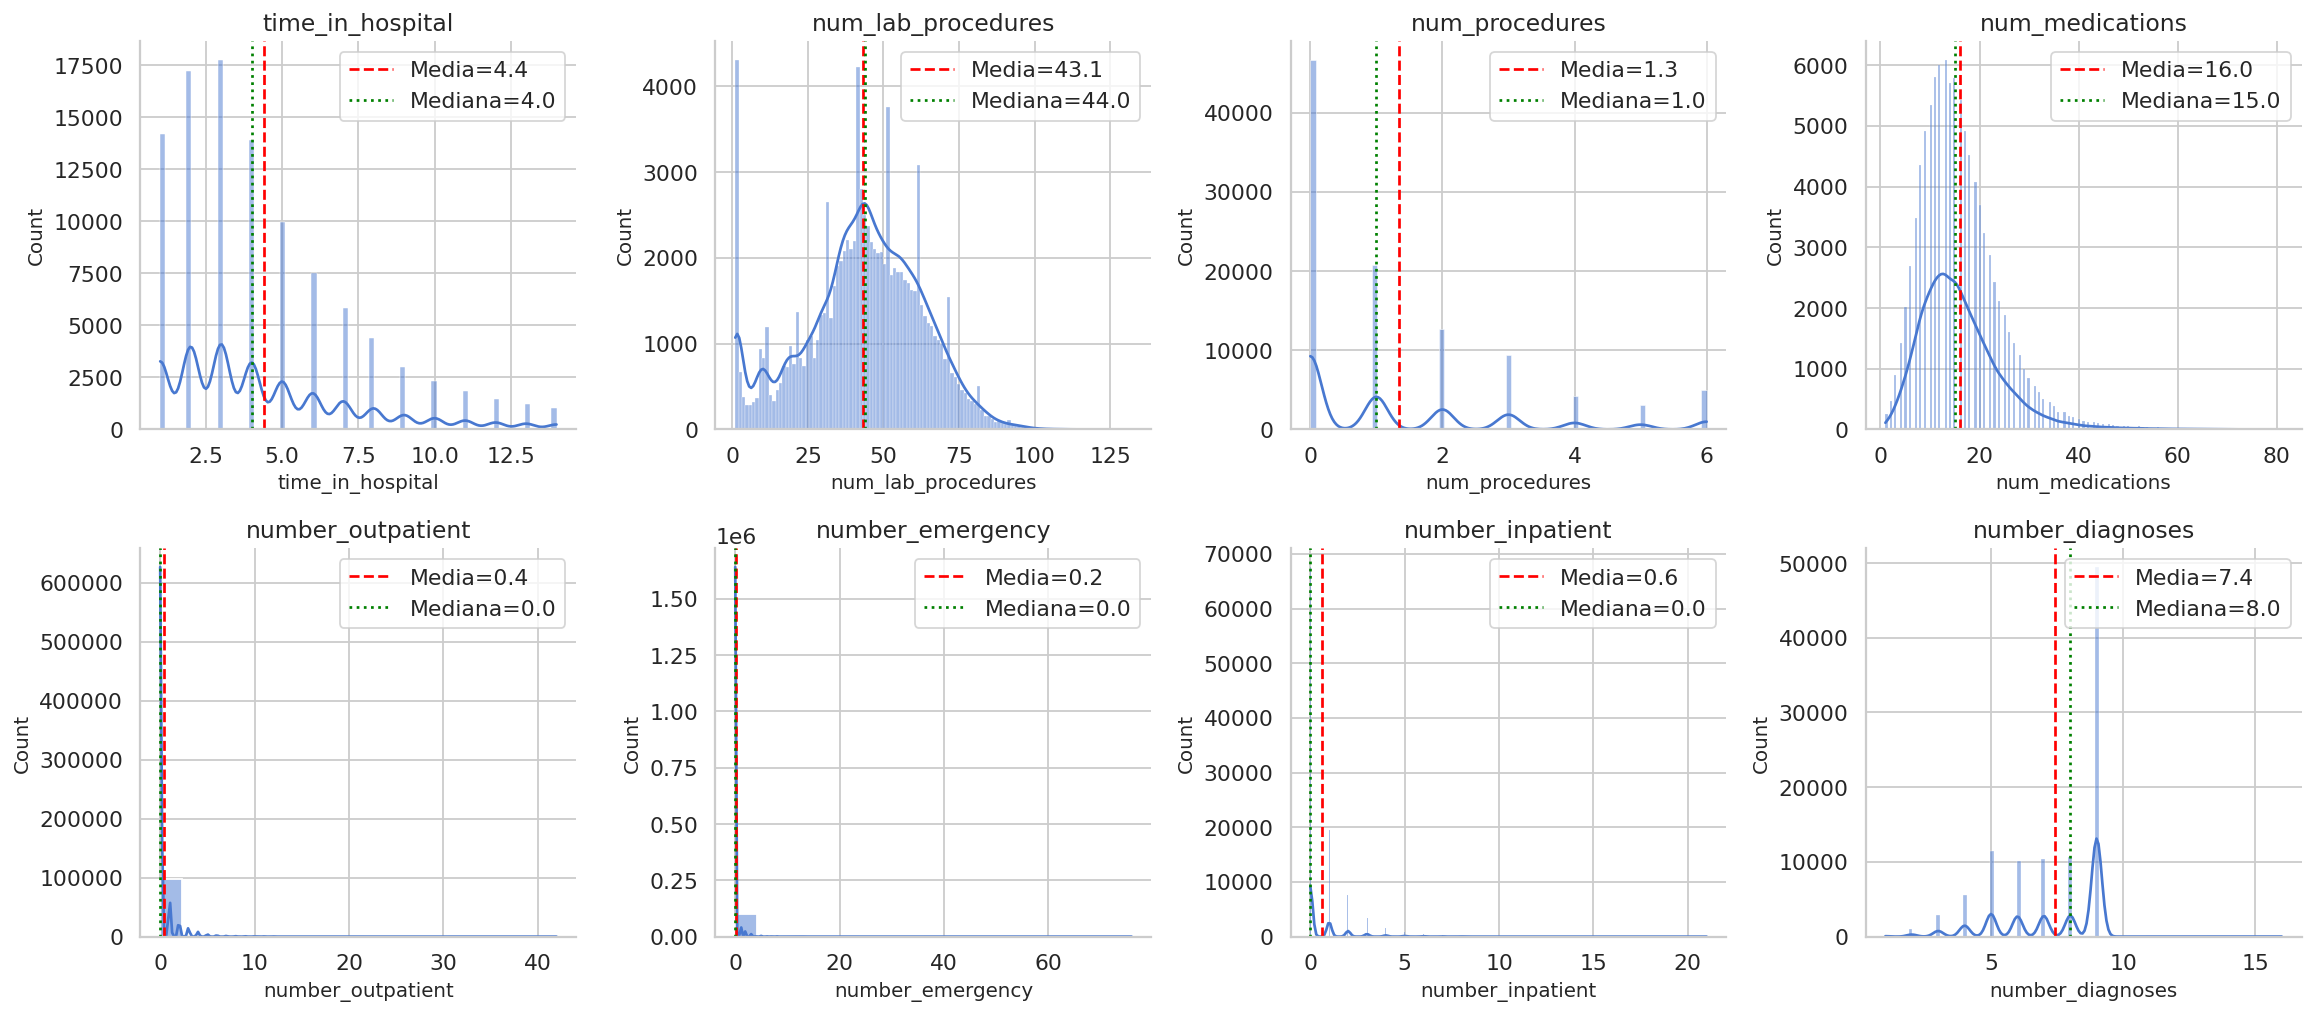

In [7]:
# ── Histogramas + KDE de variables numéricas ─────────────────────────────────
# ==========================
# DISTRIBUCIONES MARGINALES
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas relevantes
feat_num = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Estadísticos descriptivos
display(df[feat_num].describe().round(2))

# Histogramas
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feat_num):
    sns.histplot(df[col], kde=True, ax=axes[i])

    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    label=f"Media={df[col].mean():.1f}")
    axes[i].axvline(df[col].median(), color='green', linestyle=':',
                    label=f"Mediana={df[col].median():.1f}")

    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()


Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

VARIABLE: race


,Frecuencia,Porcentaje (%)
race,,
Caucasian,76099,74.78
AfricanAmerican,19210,18.88
?,2273,2.23
Hispanic,2037,2.00
Other,1506,1.48
Asian,641,0.63



VARIABLE: gender


,Frecuencia,Porcentaje (%)
gender,,
Female,54708,53.76
Male,47055,46.24
Unknown/Invalid,3,0.00



VARIABLE: age


...

,Frecuencia,Porcentaje (%)
change,,
No,54755,53.8
Ch,47011,46.2



VARIABLE: diabetesMed


,Frecuencia,Porcentaje (%)
diabetesMed,,
Yes,78363,77.0
No,23403,23.0



VARIABLE: readmitted


,Frecuencia,Porcentaje (%)
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


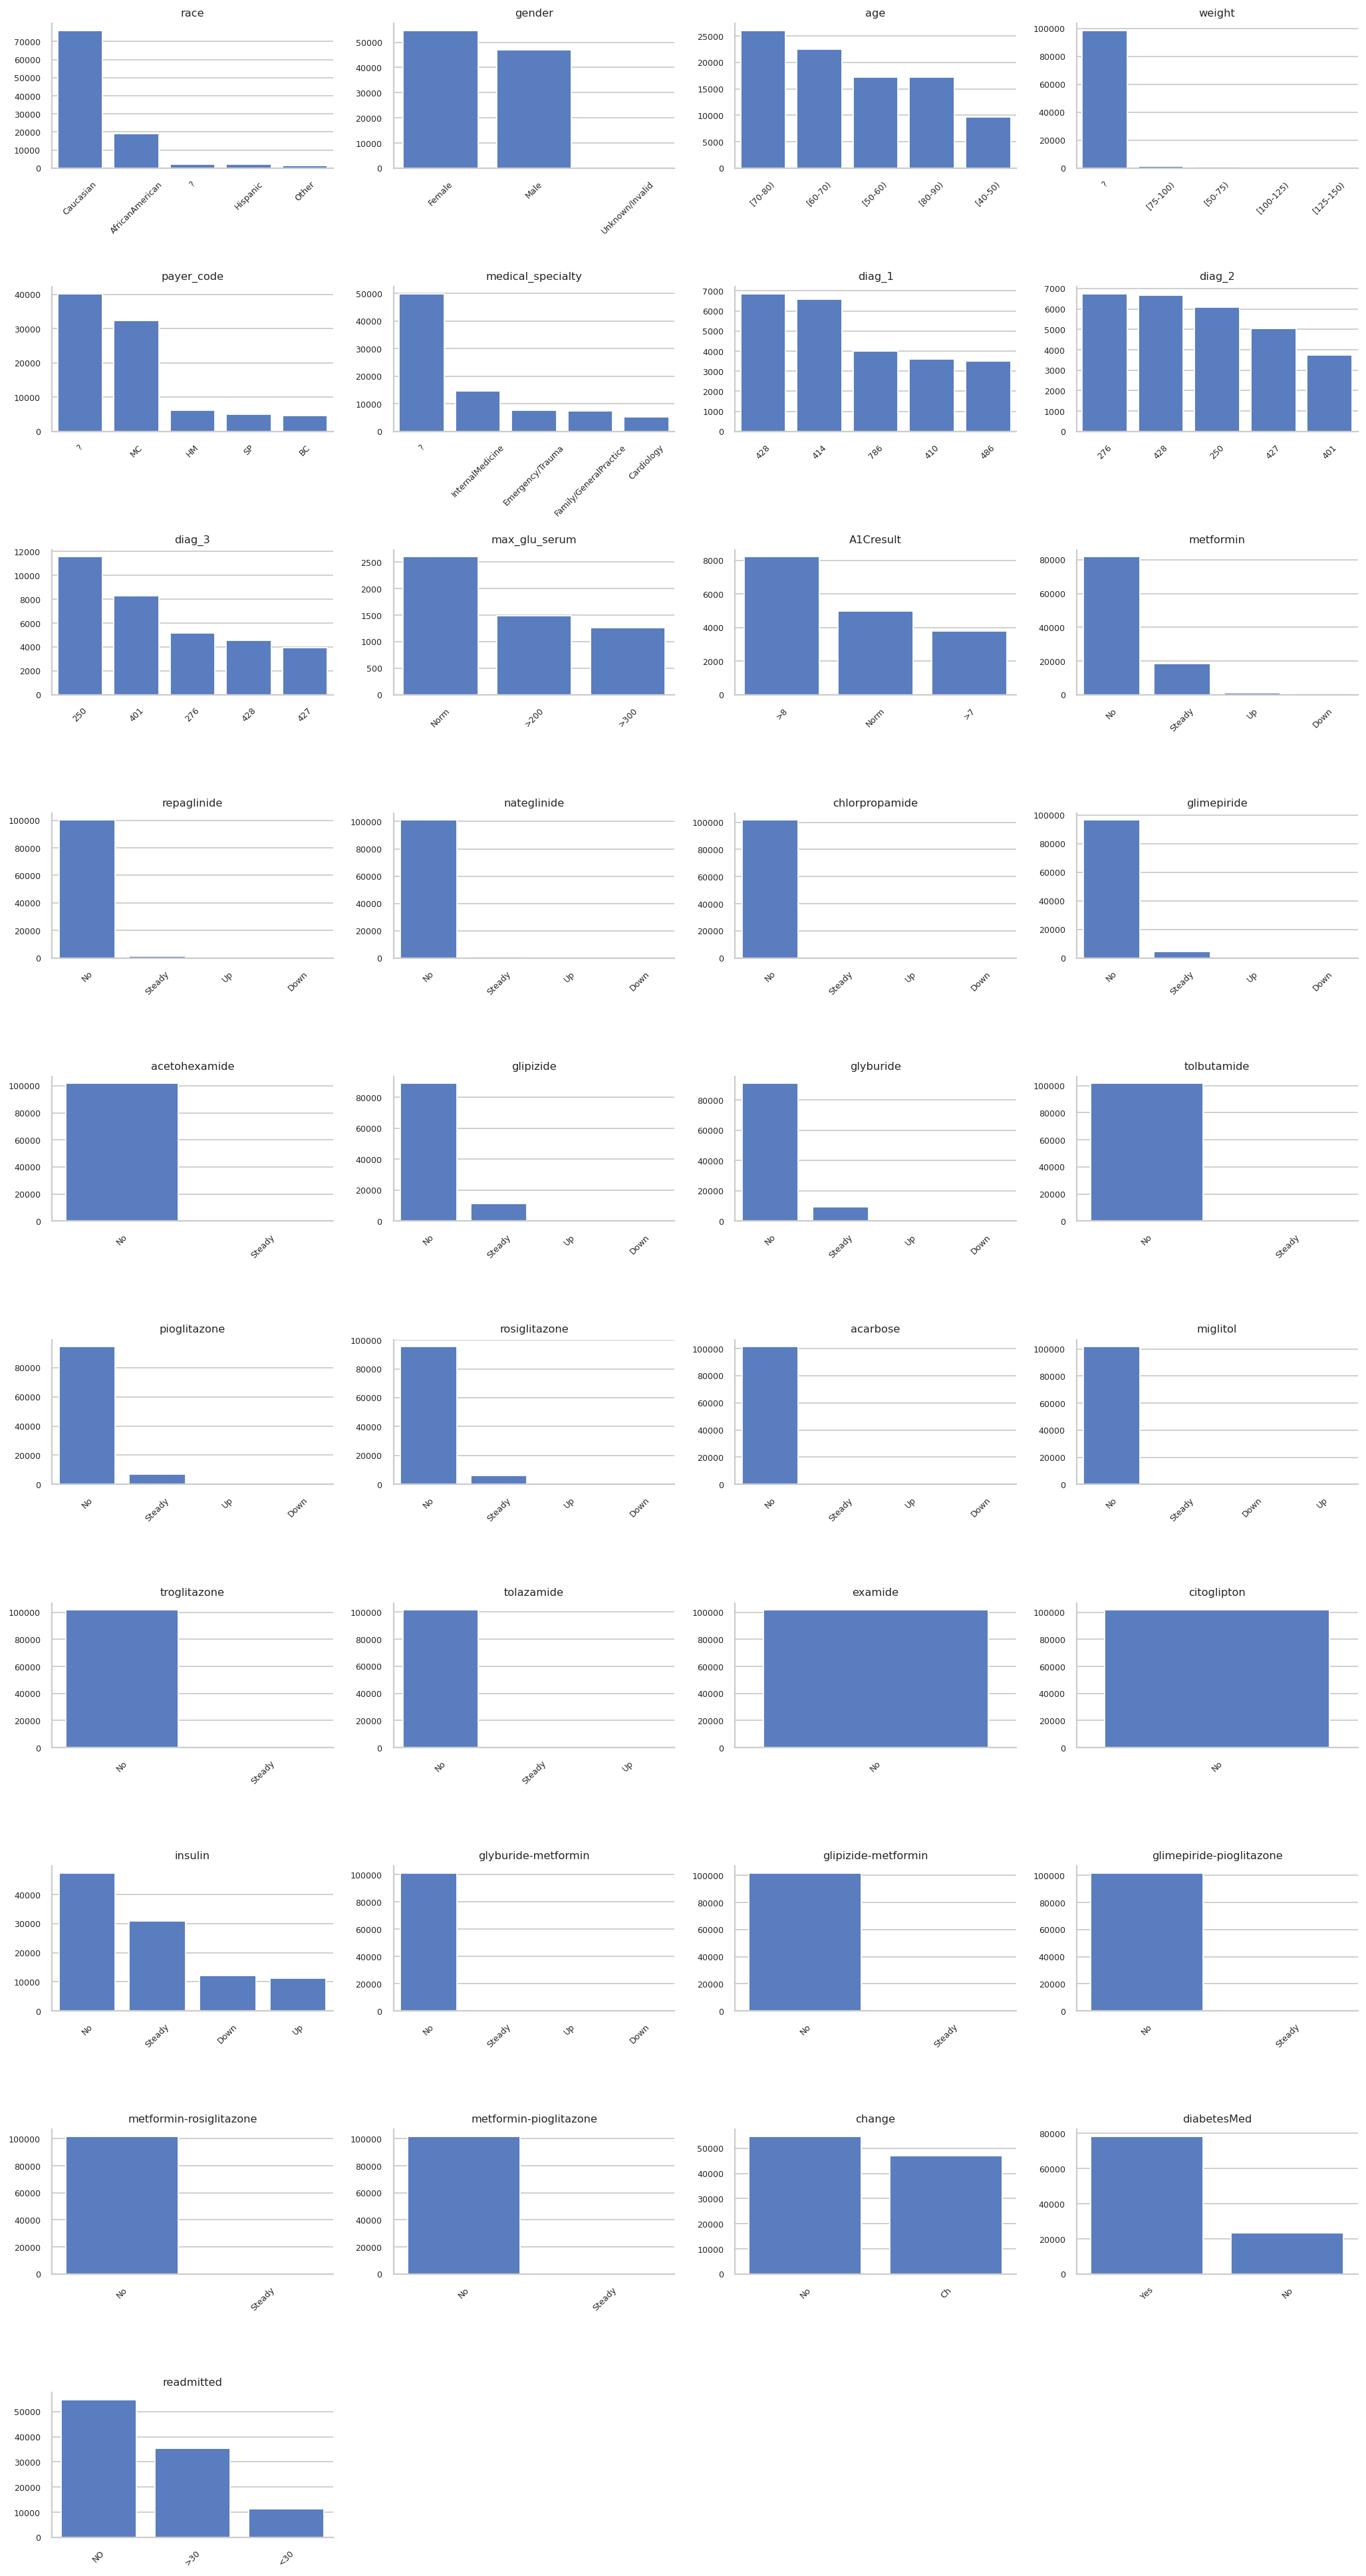

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)
for col in cat_cols:
    print(f"\n{'='*60}")
    print(f"VARIABLE: {col}")

    tabla = pd.DataFrame({
        'Frecuencia': df[col].value_counts(),
        'Porcentaje (%)': round(df[col].value_counts(normalize=True)*100,2)
    })

    display(tabla.head(10))

import matplotlib.pyplot as plt
import seaborn as sns
import math

cat_cols = df.select_dtypes(include=['object']).columns

n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3*n_rows)  # más compacto
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    top_cat = df[col].value_counts().head(5).index

    sns.countplot(
        data=df,
        x=col,
        order=top_cat,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# eliminar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretación — Variables numéricas

- **`time_in_hospital`**: La distribución es aproximadamente simétrica con leve sesgo positivo. La mayoría de las internaciones dura entre 1 y 7 días (media ≈ 4.4 días, mediana = 4). El máximo es 14 días, impuesto como criterio de inclusión del dataset.

- **`num_lab_procedures`**: Distribución aproximadamente normal centrada en ~43 procedimientos. Alta varianza (std ≈ 20). Sugiere que los pacientes diabéticos hospitalizados reciben un seguimiento intensivo.

- **`num_procedures`**: Fuertemente sesgada a la derecha. La mayoría de los pacientes tiene 0 o 1 procedimientos médicos. El máximo es 6.

- **`num_medications`**: Distribución aproximadamente normal (media ≈ 16). Refleja la complejidad farmacológica de los pacientes diabéticos, que suelen tener múltiples comorbilidades.

- **`number_outpatient`, `number_emergency`, `number_inpatient`**: Las tres presentan distribuciones extremadamente sesgadas a la derecha (la gran mayoría tiene valor 0), con outliers considerables. Esto indica que la mayoría de los encuentros ocurren en pacientes sin historia reciente de atención médica.

- **`number_diagnoses`**: Concentrado entre 5 y 9, con media ≈ 7.4. Confirma que los pacientes diabéticos hospitalizados presentan múltiples comorbilidades.


NameError: name 'labels' is not defined

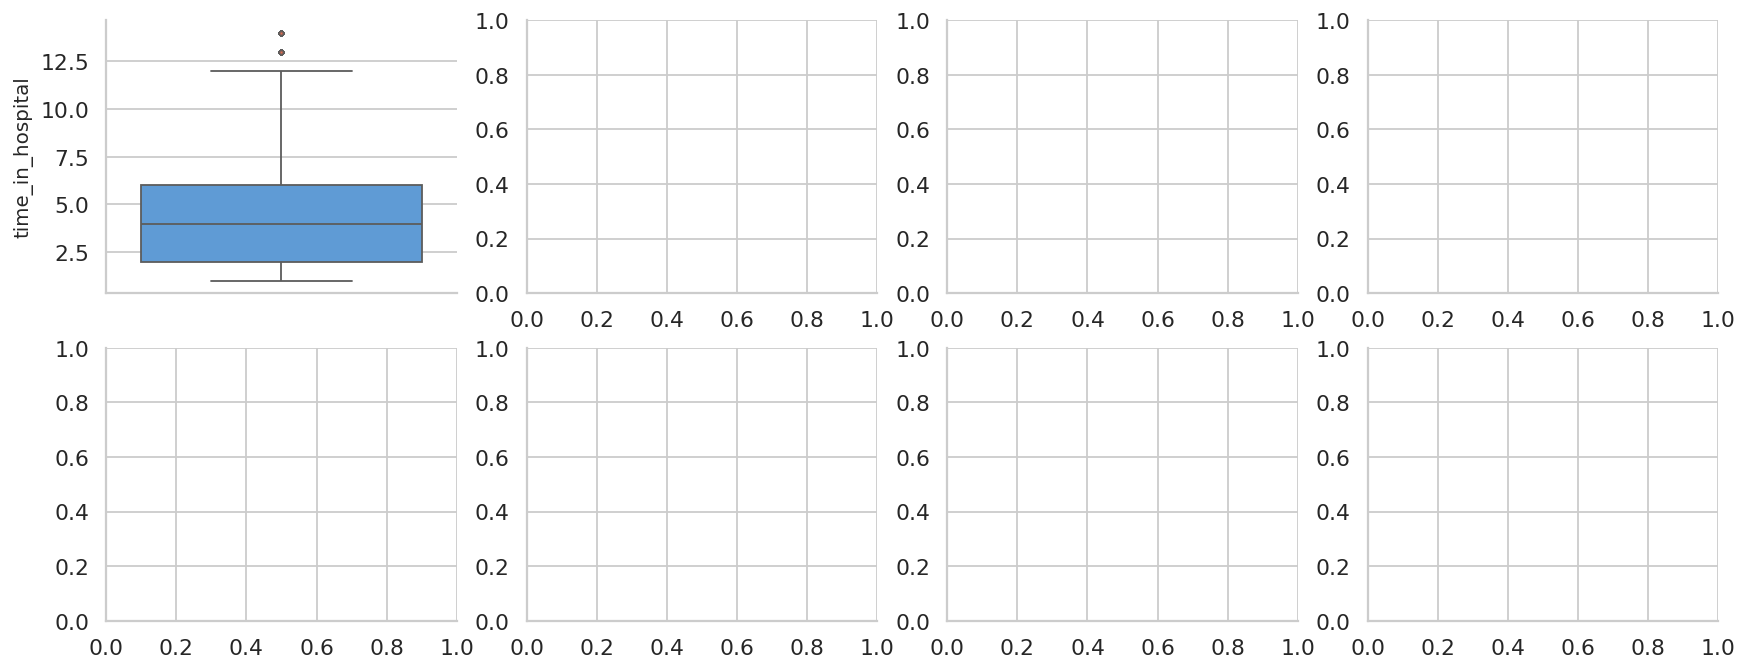

In [9]:
# ── Boxplots para comparar dispersión ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for ax, col in zip(axes, feat_num):
    sns.boxplot(y=df[col], ax=ax, color='#4C9BE8',
                flierprops=dict(marker='o', markerfacecolor='#E76F51',
                                markersize=2, alpha=0.4))
    ax.set_title(labels[col], fontsize=10)
    ax.set_xlabel('')

fig.suptitle('Boxplots de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplot_num.png', bbox_inches='tight')
plt.show()


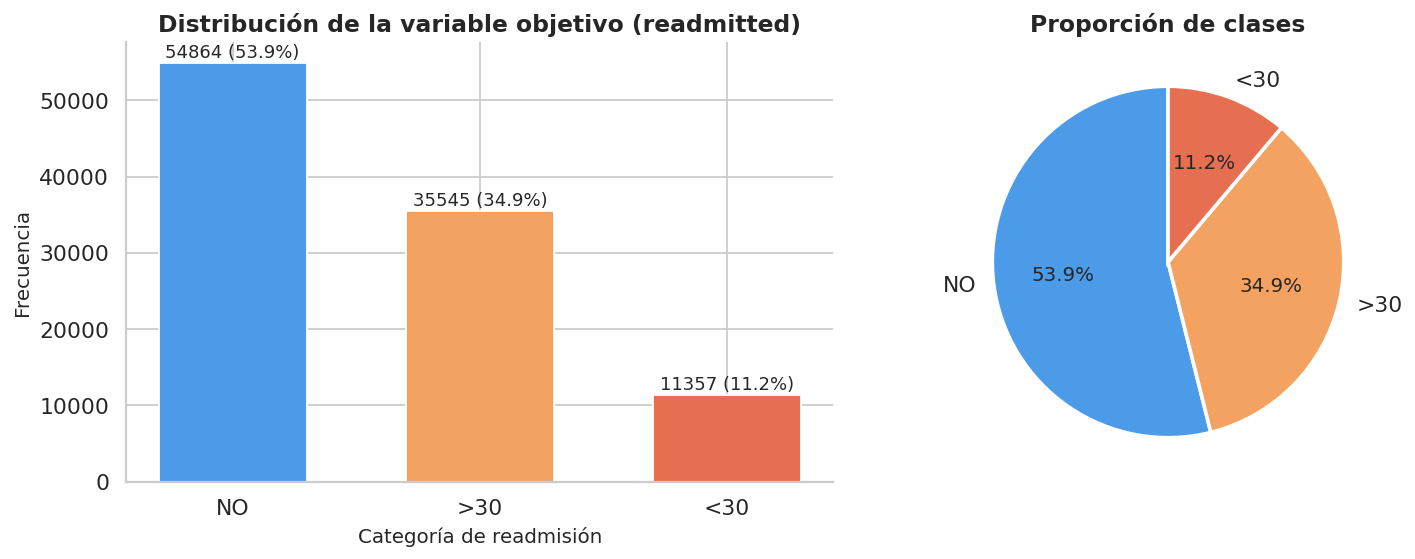


Desbalance de clases:
  NO: 54864 (53.9%)
  >30: 35545 (34.9%)
  <30: 11357 (11.2%)


In [10]:
# ── Distribución de la variable TARGET: readmitted ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

counts = df['readmitted'].value_counts()
colors = [PALETTE_TARGET[k] for k in counts.index]
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, counts.values):
    label = str(val) + " (" + str(round(100*val/len(df), 1)) + "%)"
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             label, ha='center', va='bottom', fontsize=10)

ax1.set_title('Distribución de la variable objetivo (readmitted)', fontweight='bold')
ax1.set_xlabel('Categoría de readmisión')
ax1.set_ylabel('Frecuencia')

wedges, texts, autotexts = ax2.pie(counts.values, labels=counts.index,
       colors=colors, autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts: t.set_fontsize(11)
ax2.set_title('Proporción de clases', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_target_dist.png', bbox_inches='tight')
plt.show()

print("\nDesbalance de clases:")
for cat, cnt in counts.items():
    print("  " + str(cat) + ": " + str(cnt) + " (" + str(round(100*cnt/len(df), 1)) + "%)")


##Variables faltantes

In [11]:
# Reemplazar ? por NaN
import numpy as np

df_missing = df.replace('?', np.nan)

# Cantidad y porcentaje de faltantes
missing = pd.DataFrame({
    'Faltantes': df_missing.isnull().sum(),
    '% Faltantes': round(df_missing.isnull().mean()*100,2)
})

missing = missing[missing['Faltantes'] > 0]
missing.sort_values('% Faltantes', ascending=False)

,Faltantes,% Faltantes
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


## Outliers

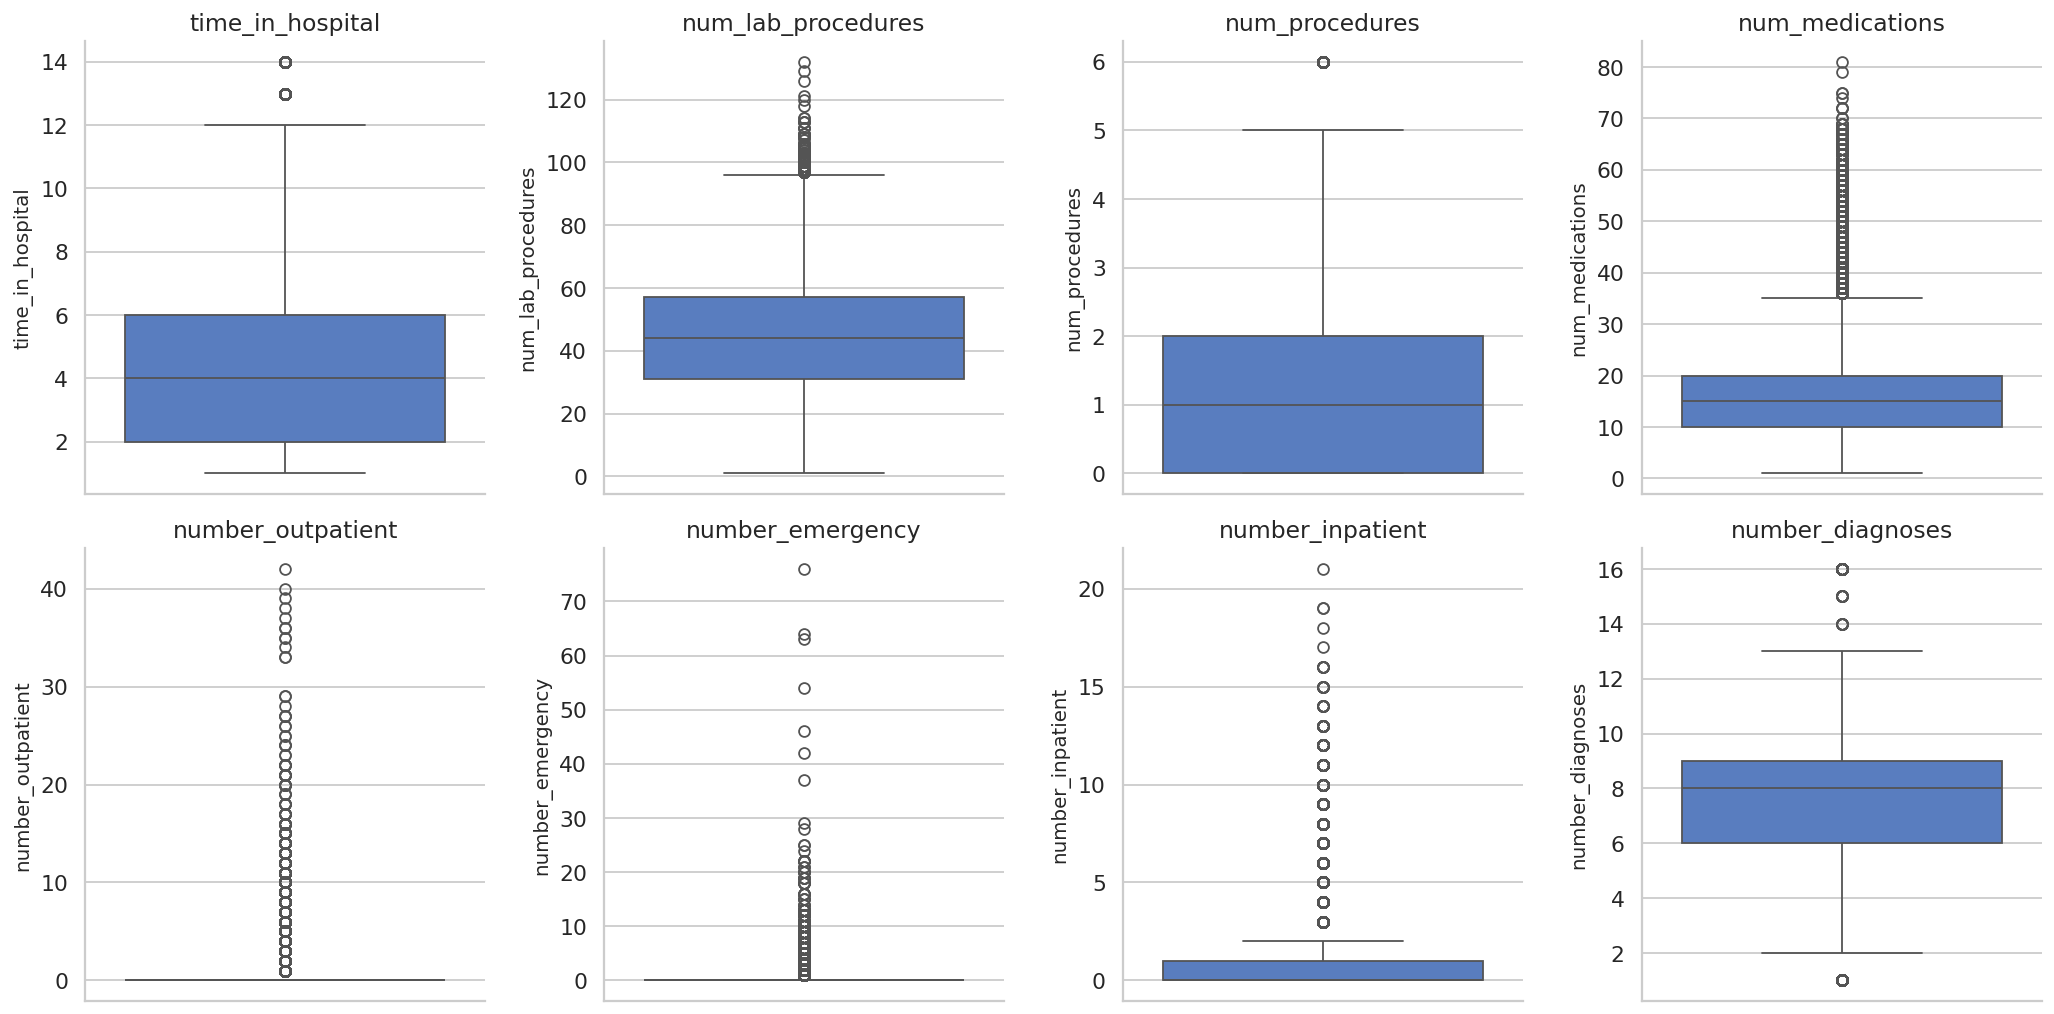

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Detectar cantidad de outliers (IQR)

In [13]:
outliers = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    outliers[col] = n_out

pd.DataFrame.from_dict(
    outliers,
    orient='index',
    columns=['Cantidad de outliers']
).sort_values('Cantidad de outliers', ascending=False)

,Cantidad de outliers
number_outpatient,16739
number_emergency,11383
number_inpatient,7049
num_procedures,4954
num_medications,2557
time_in_hospital,2252
number_diagnoses,281
num_lab_procedures,143


## Errores o valores inconsistentes

In [14]:
# Ver categorías extrañas
for col in ['race','gender','age','readmitted']:
    print(f"\n{col}")
    print(df[col].unique())


race
['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']

gender
['Female' 'Male' 'Unknown/Invalid']

age
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

readmitted
['NO' '>30' '<30']


### Interpretación — Variable objetivo `readmitted`

La variable target presenta **tres clases**:
- **NO** (no readmitido): 53.9% — mayoría de las internaciones
- **>30** (readmitido después de 30 días): 34.9%
- **<30** (readmitido dentro de los 30 días): 11.2%

Existe un **desbalance de clases moderado**. Para el modelado, esto requerirá una estrategia explícita: ya sea reformular como problema binario (`<30` vs. `resto`), o aplicar técnicas de balanceo (SMOTE, class weights, oversampling).

Clínicamente, la readmisión temprana (`<30` días) es la de mayor interés, ya que es penalizada bajo la política de salud de EE. UU. (Hospital Readmissions Reduction Program — HRRP).


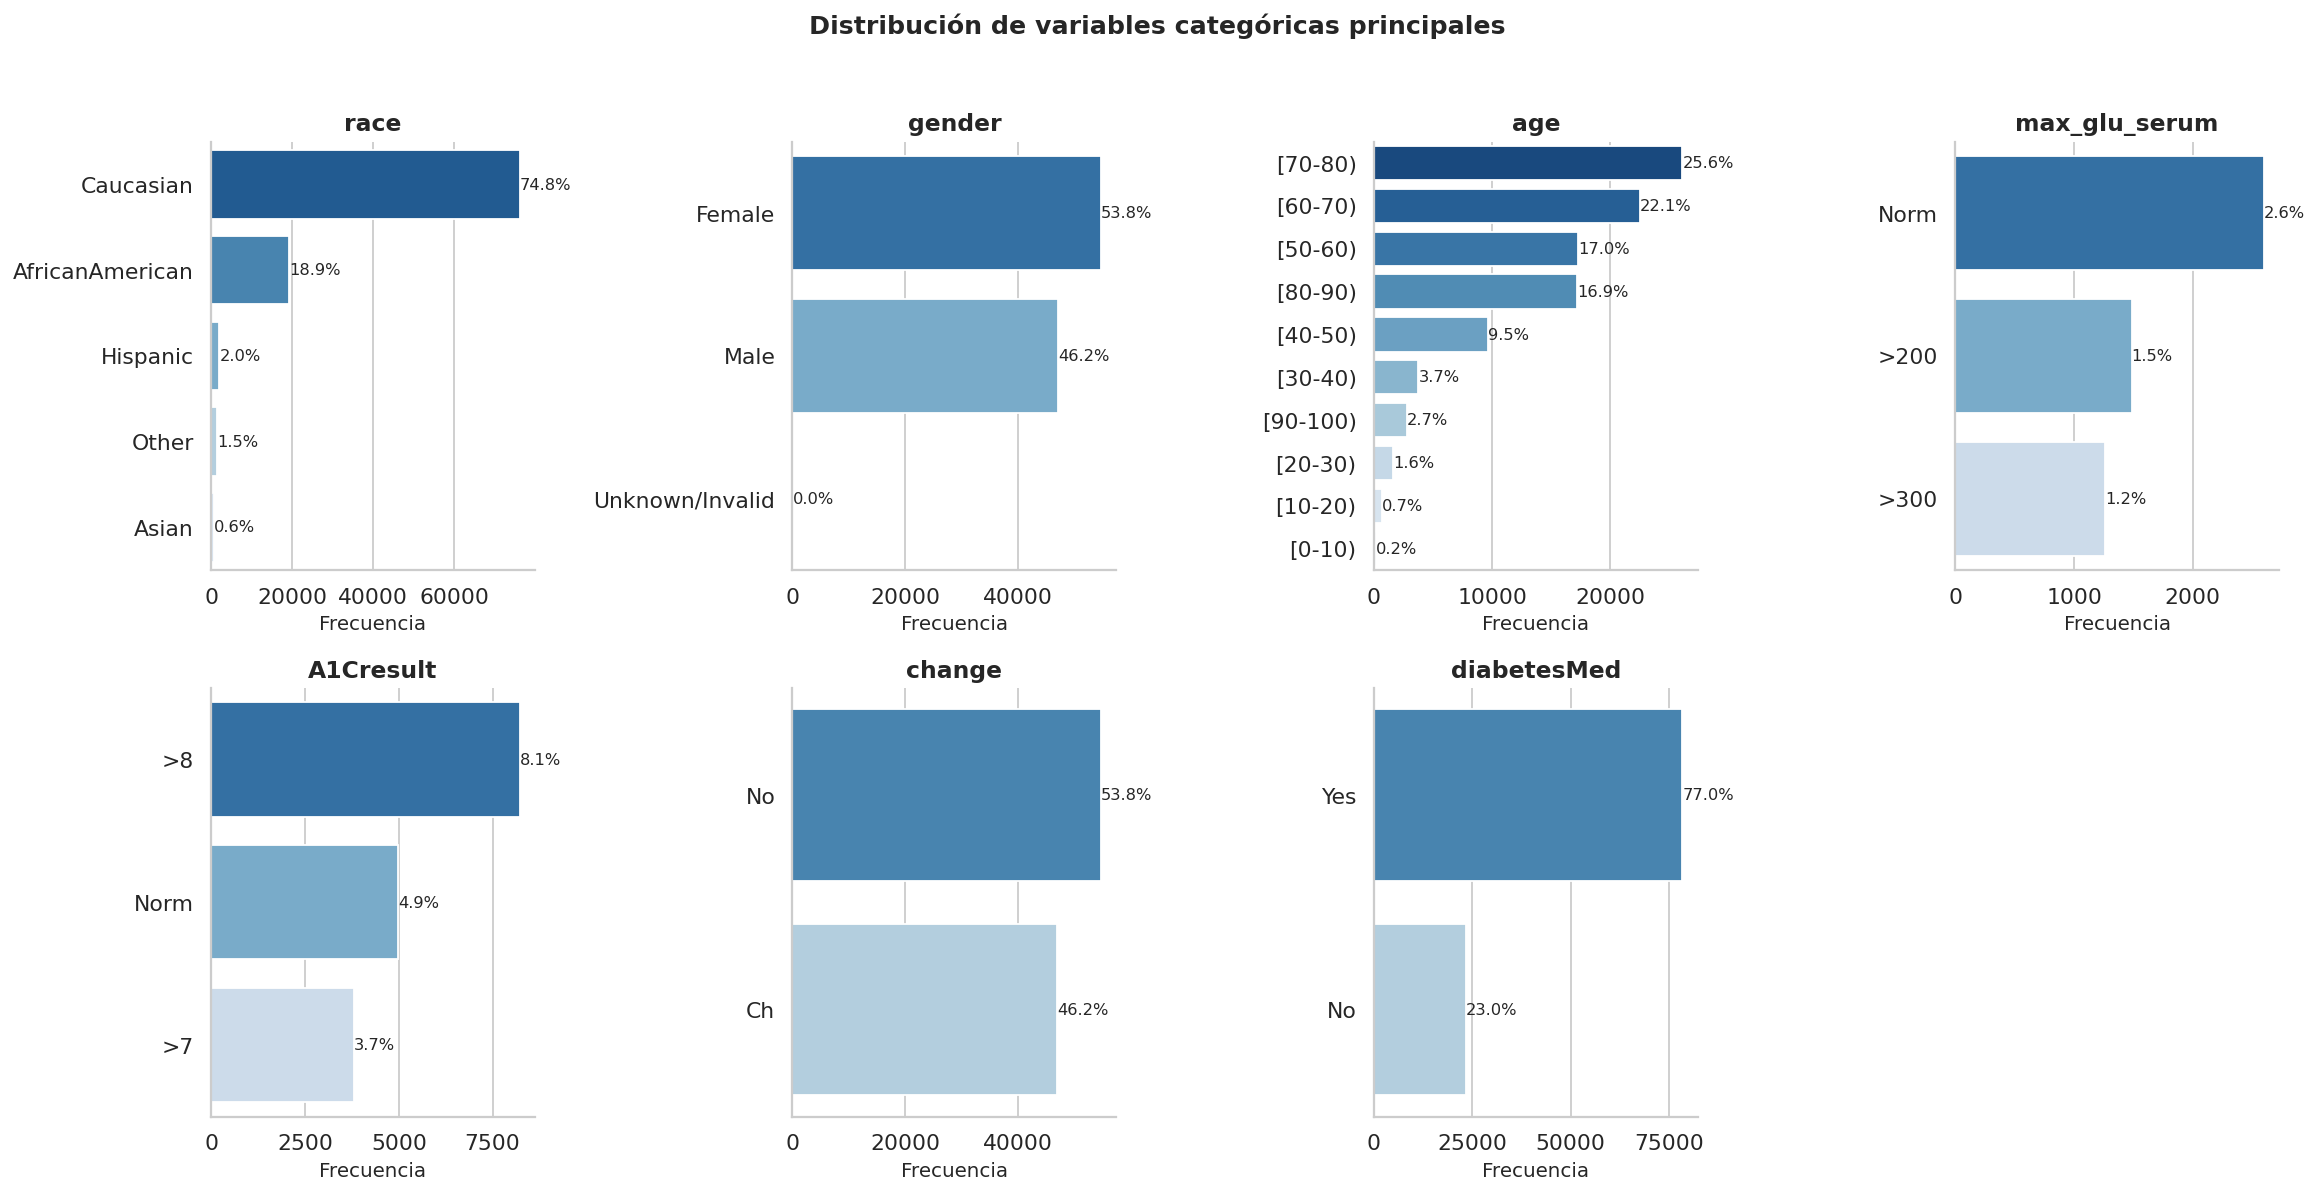

In [15]:
# ── Variables categóricas clave ──────────────────────────────────────────────
cat_key = ['race', 'gender', 'age', 'max_glu_serum', 'A1Cresult',
           'change', 'diabetesMed']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_key):
    data = df[col].replace('?', np.nan).dropna().value_counts()
    sns.barplot(x=data.values, y=data.index, ax=ax, palette='Blues_r',
                orient='h')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('')
    for i, v in enumerate(data.values):
        ax.text(v + 0.3, i, f'{100*v/len(df):.1f}%', va='center', fontsize=9)

# Ocultar último subplot vacío
axes[-1].set_visible(False)

fig.suptitle('Distribución de variables categóricas principales', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_univariado_cat.png', bbox_inches='tight')
plt.show()


### Interpretación — Variables categóricas principales

- **`race`**: La muestra está compuesta mayoritariamente por **pacientes caucásicos** (~74.8%), seguido de afroamericanos (~18.9%). La distribución racial refleja tanto la demografía de EE. UU. como posibles sesgos de acceso al sistema de salud.

- **`gender`**: Distribución relativamente equilibrada: 53.8% femenino, 46.2% masculino. Tres registros presentan `Unknown/Invalid` (despreciable).

- **`age`**: La mayoría de los pacientes son **adultos mayores**: los grupos `[70-80)` y `[60-70)` concentran casi el 50% de los registros. Menos del 3% son menores de 30 años, lo cual es consistente con la epidemiología de la diabetes tipo 2.

- **`max_glu_serum`**: El 96.4% de los registros tienen valor `None` (no se realizó la prueba). Entre quienes la tienen, la distribución es variada. Esta variable tendrá alta tasa de faltantes funcionales.

- **`A1Cresult`**: Similar a la anterior, el 83.3% no tiene resultado. De los que sí tienen, la mayoría muestra valores elevados (`>8`), indicando mal control glucémico.

- **`change`**: El 46.2% de los pacientes tuvo un **cambio en su medicación** durante la internación.

- **`diabetesMed`**: El 77.0% de los pacientes tenía **medicación antidiabética** prescripta, lo cual es esperable en este contexto.


---
## 4. Análisis Bivariado

### 4.1 Correlaciones entre variables numéricas


In [16]:
df[feat_num].corr().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.00,0.32,0.19,0.47,-0.01,-0.01,0.07,0.22
num_lab_procedures,0.32,1.00,0.06,0.27,-0.01,-0.00,0.04,0.15
num_procedures,0.19,0.06,1.00,0.39,-0.02,-0.04,-0.07,0.07
num_medications,0.47,0.27,0.39,1.00,0.05,0.01,0.06,0.26
number_outpatient,-0.01,-0.01,-0.02,0.05,1.00,0.09,0.11,0.09
number_emergency,-0.01,-0.00,-0.04,0.01,0.09,1.00,0.27,0.06
number_inpatient,0.07,0.04,-0.07,0.06,0.11,0.27,1.00,0.10
number_diagnoses,0.22,0.15,0.07,0.26,0.09,0.06,0.10,1.00


### Interpretación — Correlaciones

Las correlaciones entre variables numéricas son en general **moderadas o bajas**, lo que sugiere que aportan información relativamente independiente:

- **`time_in_hospital` ↔ `num_lab_procedures`** (r ≈ 0.44): A mayor tiempo de internación, más procedimientos de laboratorio. Relación esperable.
- **`time_in_hospital` ↔ `num_medications`** (r ≈ 0.46): Pacientes con estadías más prolongadas reciben más medicamentos. Posible confusión con la severidad del cuadro.
- **`num_medications` ↔ `num_lab_procedures`** (r ≈ 0.45): Correlación razonable.
- **`number_outpatient`, `number_emergency`, `number_inpatient`**: Correlaciones muy bajas entre sí y con el resto.

No se observan correlaciones muy altas (>0.8) que sugieran multicolinealidad severa entre estas variables.


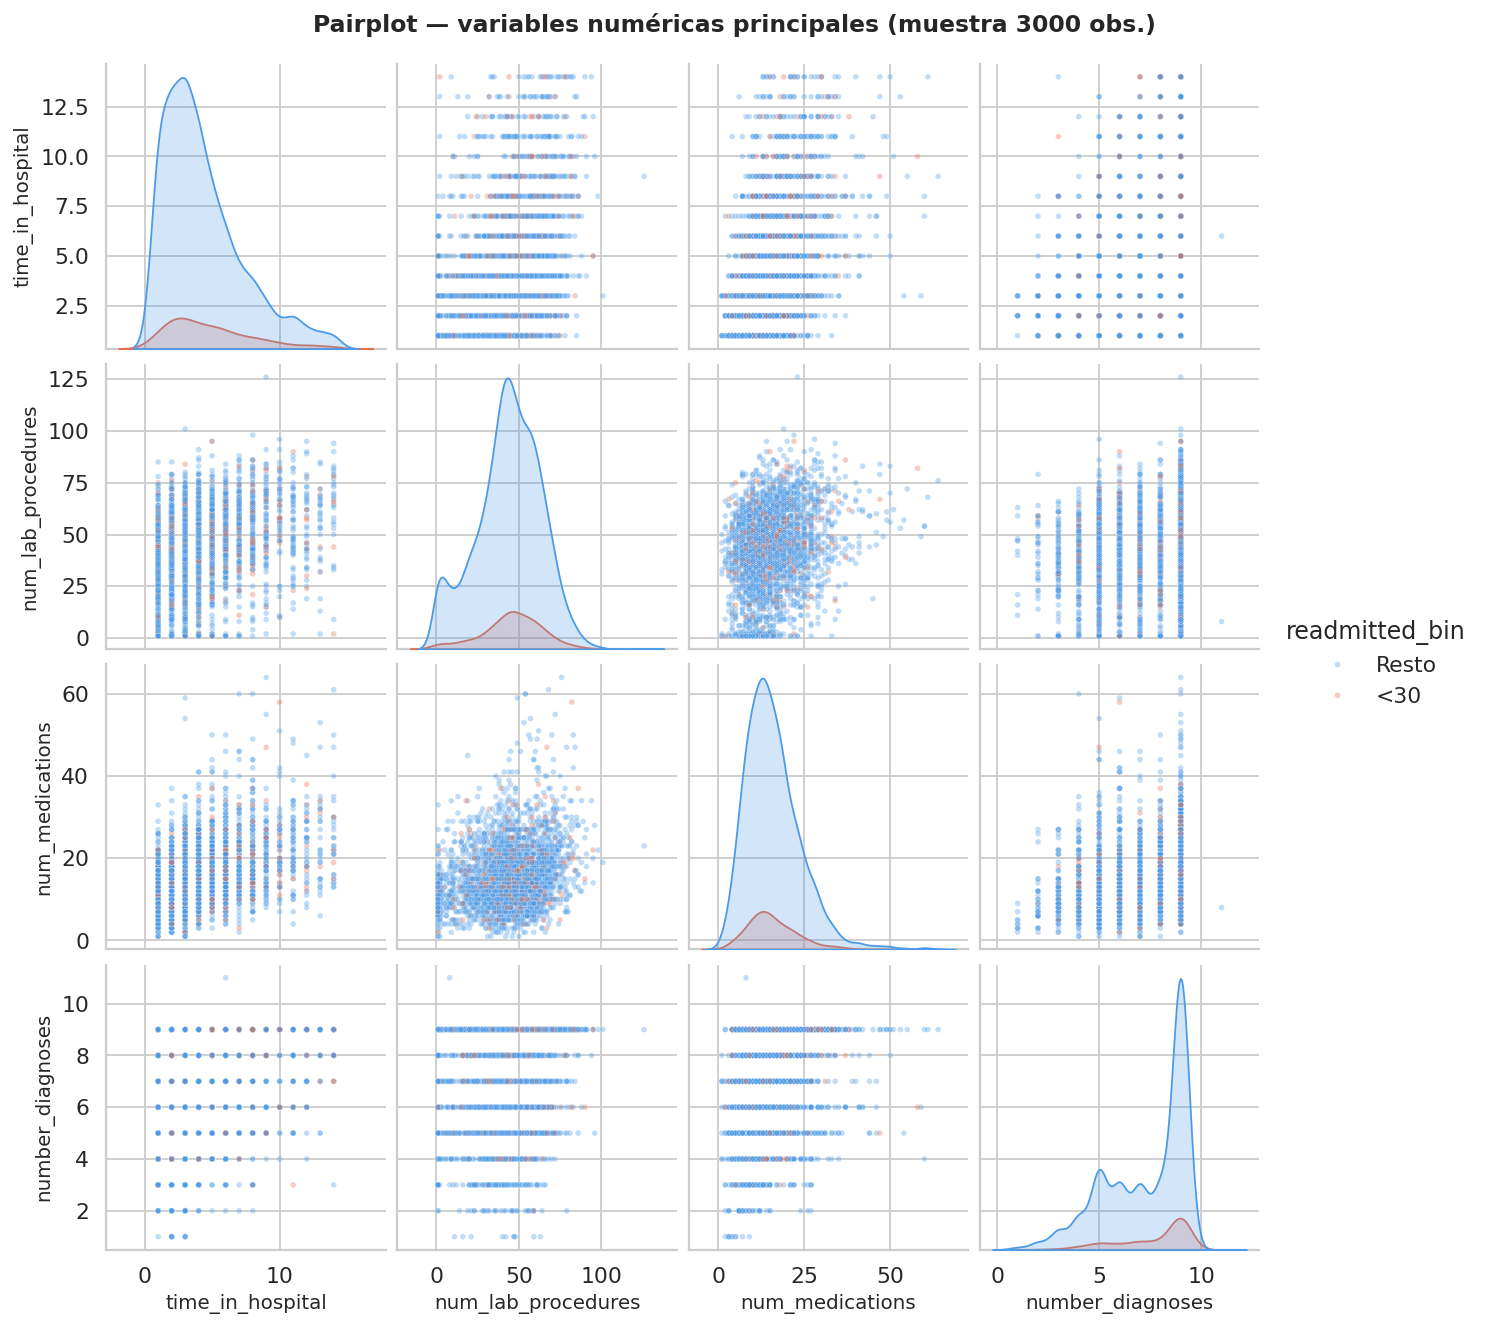

In [17]:
# ── Scatterplot matrix de variables numéricas principales ────────────────────
top4 = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']

# Binario para color: readmitido en <30 días vs. el resto
df['readmitted_bin'] = df['readmitted'].apply(lambda x: '<30' if x == '<30' else 'Resto')

g = sns.pairplot(df[top4 + ['readmitted_bin']].sample(3000, random_state=42),
                 hue='readmitted_bin',
                 palette={'<30': '#E76F51', 'Resto': '#4C9BE8'},
                 plot_kws=dict(alpha=0.35, s=10),
                 diag_kind='kde')
g.figure.suptitle('Pairplot — variables numéricas principales (muestra 3000 obs.)',
                   y=1.02, fontsize=13, fontweight='bold')
plt.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()


NameError: name 'labels' is not defined

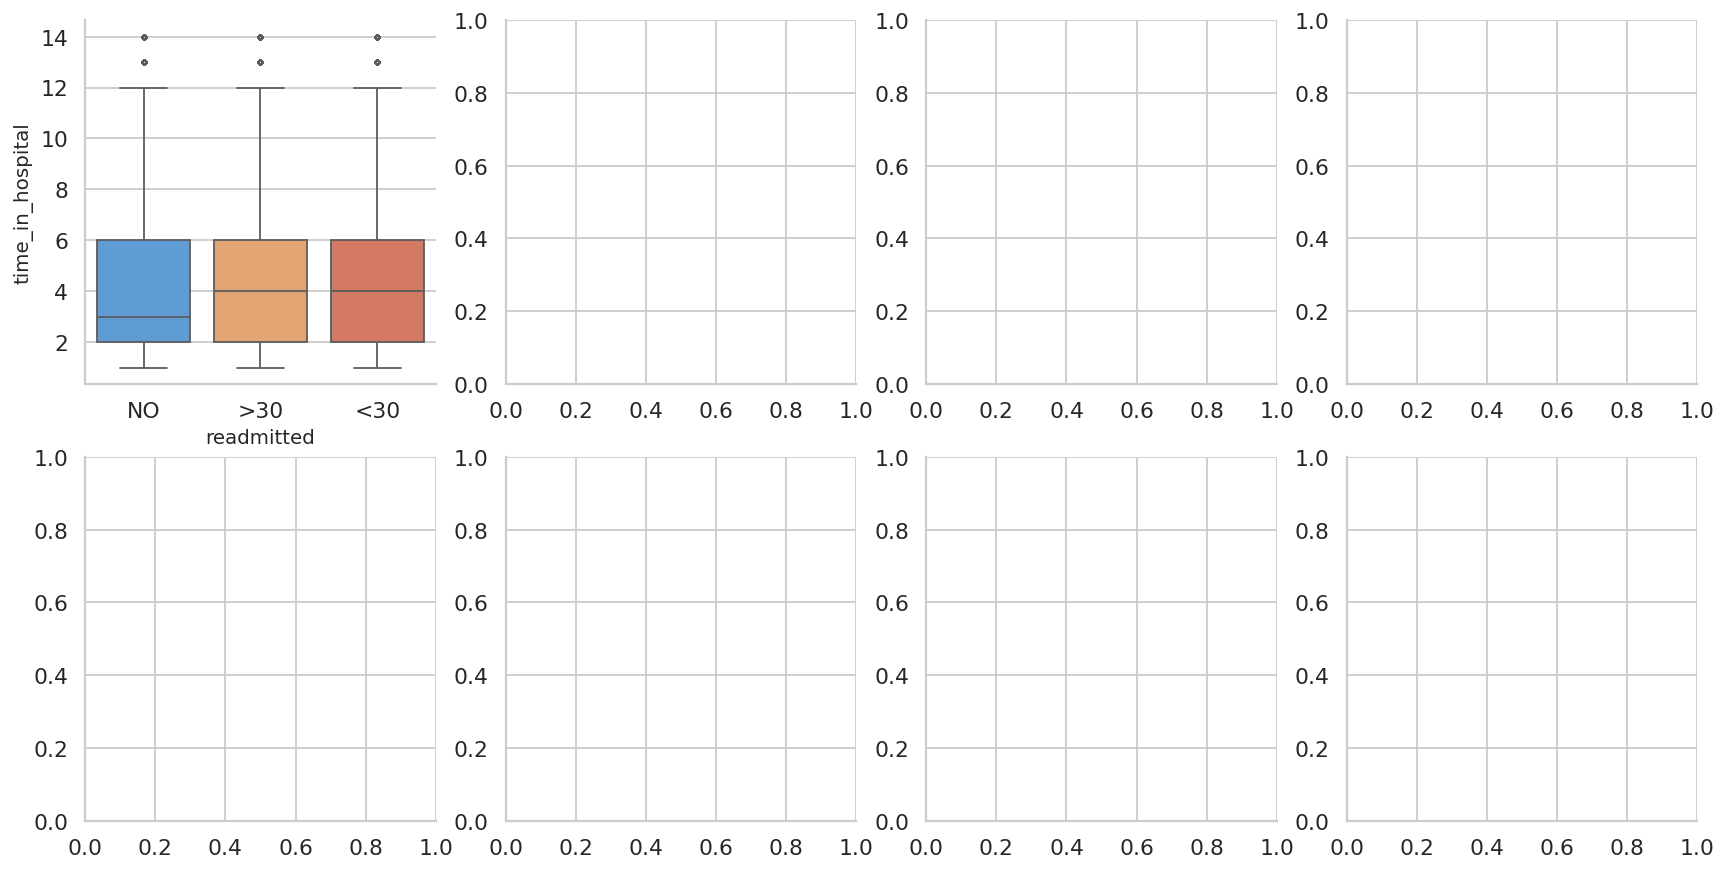

In [18]:
# ── Variables numéricas vs. readmitted ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
order = ['NO', '>30', '<30']
palette = [PALETTE_TARGET[k] for k in order]

for ax, col in zip(axes, feat_num):
    sns.boxplot(data=df, x='readmitted', y=col, order=order,
                palette=palette, ax=ax,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(labels[col], fontsize=10)
    ax.set_xlabel('')

fig.suptitle('Variables numéricas por categoría de readmisión', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_biv_num_target.png', bbox_inches='tight')
plt.show()


### Interpretación — Variables numéricas vs. readmisión

Los boxplots revelan patrones relevantes:

- **`time_in_hospital`**: Los pacientes readmitidos dentro de los 30 días (`<30`) tienden a tener estadías ligeramente **más largas** que los no readmitidos, aunque el solapamiento es considerable.

- **`num_lab_procedures`**: Los pacientes `<30` muestran una mediana similar pero mayor varianza. No es un discriminador muy fuerte por sí solo.

- **`num_medications`**: Los pacientes readmitidos tempranamente presentan mayor cantidad de medicamentos, lo que puede reflejar mayor complejidad clínica.

- **`number_inpatient`**: Las **internaciones previas** son el mejor discriminador entre grupos. Los pacientes con readmisión `<30` tienen claramente más internaciones previas, lo que indica que son pacientes crónicos con mayor fragilidad.

- **`number_diagnoses`**: Los readmitidos tempranamente tienen ligeramente más diagnósticos, consistente con mayor comorbilidad.


In [ ]:
# ── Variables categóricas vs. readmitted ────────────────────────────────────
def plot_cat_vs_target(col, ax, title):
    ct = pd.crosstab(df[col].replace('?', 'Desconocido'), df['readmitted'],
                     normalize='index')[['NO', '>30', '<30']] * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[PALETTE_TARGET[k] for k in ['NO', '>30', '<30']],
            edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% dentro de la categoría')
    ax.legend(title='Readmitido', fontsize=8, loc='upper right')
    ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cat_vs_target('age', axes[0], 'Readmisión por grupo etario')
plot_cat_vs_target('race', axes[1], 'Readmisión por raza')
plot_cat_vs_target('gender', axes[2], 'Readmisión por género')
plot_cat_vs_target('diabetesMed', axes[3], 'Readmisión por medicación antidiabética')
plot_cat_vs_target('change', axes[4], 'Readmisión por cambio de medicación')
plot_cat_vs_target('A1Cresult', axes[5], 'Readmisión por resultado A1C')

fig.suptitle('Variables categóricas vs. readmisión hospitalaria',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_biv_cat_target.png', bbox_inches='tight')
plt.show()


### Interpretación — Variables categóricas vs. readmisión

- **Edad**: La proporción de readmisión `<30` es relativamente estable entre grupos etarios (entre 9% y 13%), aunque los grupos de mayor edad tienen tasas algo más altas. Esto es consistente con la mayor fragilidad clínica del adulto mayor.

- **Raza**: No se observan diferencias dramáticas entre razas en cuanto a readmisión. Sin embargo, esto puede estar parcialmente explicado por la distribución desigual de la muestra (predominio caucásico).

- **Género**: La diferencia entre géneros es mínima.

- **`diabetesMed`**: Los pacientes con medicación antidiabética presentan una proporción levemente **mayor** de readmisión `<30`, probablemente porque representan casos más severos o crónicos.

- **`change`**: Los pacientes con cambio de medicación durante la internación tienen una tasa de readmisión `<30` levemente mayor. Podría reflejar la mayor complejidad del manejo clínico.

- **`A1Cresult`**: La variable presenta muchos faltantes (`None`). Entre quienes sí tienen resultado, los valores normales (`Norm`) presentan la menor tasa de readmisión temprana, lo que tiene sentido clínico: mejor control glucémico → menor riesgo.


In [ ]:
# ── Uso de insulina vs. readmisión ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
ct = pd.crosstab(df['insulin'], df['readmitted'], normalize='index')[['NO', '>30', '<30']] * 100
ct.plot(kind='bar', stacked=True, ax=ax,
        color=[PALETTE_TARGET[k] for k in ['NO', '>30', '<30']],
        edgecolor='white', linewidth=0.5)
ax.set_title('Readmisión por tipo de manejo de insulina', fontweight='bold')
ax.set_xlabel('Insulina (cambio)')
ax.set_ylabel('% dentro de la categoría')
ax.legend(title='Readmitido')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('fig_insulin_target.png', bbox_inches='tight')
plt.show()


### Interpretación — Insulina vs. readmisión

La insulina es la variable de medicamento más frecuentemente prescripta y con mayor variación. Los pacientes con insulina `Up` (dosis aumentada) muestran tasas de readmisión `<30` levemente superiores, lo que podría indicar mayor inestabilidad en el control glucémico. En contraste, los que mantienen dosis `Steady` tienen el mejor perfil de no-readmisión.


---
## 5. Calidad de datos

### 5.1 Valores faltantes codificados como `'?'`


In [21]:
# ── Cuantificación de '?' por variable ──────────────────────────────────────
missing_q = {}
for col in df.columns:
    if df[col].dtype == object:
        n = (df[col] == '?').sum()
        if n > 0:
            missing_q[col] = n

missing_df = pd.DataFrame({
    'Variable': list(missing_q.keys()),
    'N faltantes (?)': list(missing_q.values()),
    '% faltantes': [100*v/len(df) for v in missing_q.values()]
}).sort_values('% faltantes', ascending=False).reset_index(drop=True)

print(missing_df.to_string(index=False))


         Variable  N faltantes (?)  % faltantes
           weight            98569    96.858479
medical_specialty            49949    49.082208
       payer_code            40256    39.557416
             race             2273     2.233555
           diag_3             1423     1.398306
           diag_2              358     0.351787
           diag_1               21     0.020636


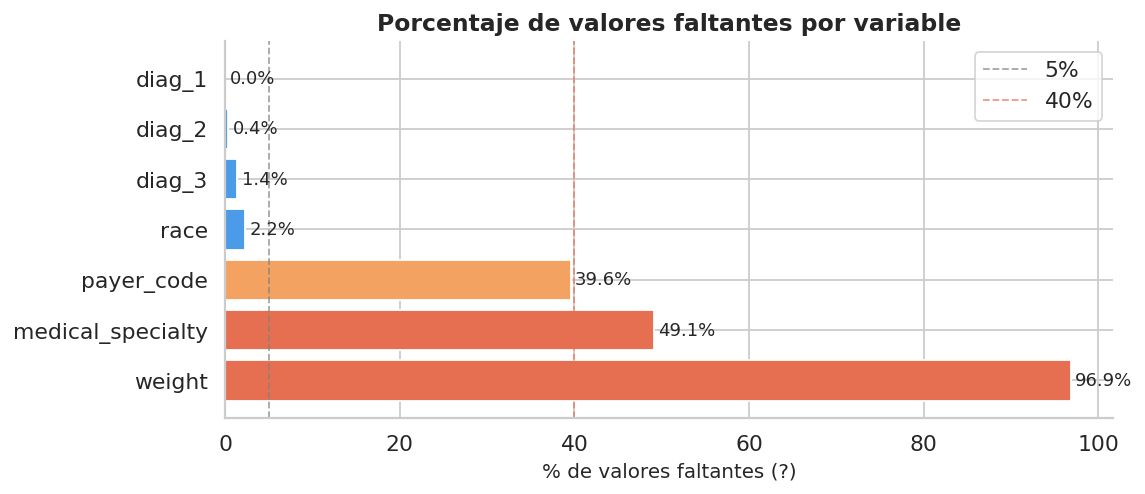

In [22]:
# ── Visualización de faltantes ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df['Variable'], missing_df['% faltantes'],
               color=['#E76F51' if v > 40 else '#F4A261' if v > 5 else '#4C9BE8'
                      for v in missing_df['% faltantes']],
               edgecolor='white')
ax.set_xlabel('% de valores faltantes (?)')
ax.set_title('Porcentaje de valores faltantes por variable', fontweight='bold')
ax.axvline(5, color='gray', ls='--', lw=1, alpha=0.7, label='5%')
ax.axvline(40, color='#E76F51', ls='--', lw=1, alpha=0.7, label='40%')
ax.legend()
for bar, val in zip(bars, missing_df['% faltantes']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_missing.png', bbox_inches='tight')
plt.show()


### 5.2 Clasificación de faltantes (MCAR / MAR / MNAR)

| Variable | % faltantes | Clasificación | Justificación |
|---|---|---|---|
| `weight` | 96.9% | **MNAR** | El peso del paciente probablemente no se registra cuando no es relevante clínicamente o cuando el paciente no puede ser pesado. La ausencia de dato está relacionada con la condición del paciente. |
| `medical_specialty` | 49.1% | **MAR** | La especialidad del médico tratante puede no registrarse sistemáticamente en ciertos hospitales o tipos de internación. La ausencia está relacionada con características del encuentro (hospital, tipo de admisión) pero no con la especialidad en sí. |
| `payer_code` | 39.6% | **MAR** | El código de pagador puede no registrarse en contextos de emergencia o en hospitales que no lo requieren. Relacionado con el tipo de admisión. |
| `race` | 2.2% | **MAR** | La raza puede no registrarse en ciertos contextos o por políticas de privacidad. Probablemente relacionada con el hospital o región geográfica. |
| `diag_2` | 0.4% | **MCAR** | Un pequeño porcentaje de registros sin segundo diagnóstico parece aleatório; posiblemente errores de carga o pacientes con un único diagnóstico primario. |
| `diag_3` | 1.4% | **MCAR** / **MAR** | Similar a `diag_2`. Algunos pacientes genuinamente no tienen tercer diagnóstico. |
| `diag_1` | 0.0% | **MCAR** | Solo 21 registros. Casi con certeza errores de carga. |

### Implicancias para el modelado:

- **`weight`** (96.9% faltante): Esta variable es prácticamente inutilizable en su forma actual. Se recomienda **eliminarla** o crear una variable binaria `weight_recorded` que capture si se registró o no.
- **`medical_specialty`** y **`payer_code`**: Pueden utilizarse si se trata el faltante como una categoría propia (`'Desconocido'`) ya que el mecanismo MAR implica que la ausencia puede ser informativa.
- **`race`**: Imputación por moda o tratamiento como categoría extra. Dado el sesgo potencial, debe manejarse con cuidado.
- **`diag_1/2/3`**: Los pocos faltantes pueden imputarse con una categoría genérica o eliminarse sin impacto significativo.


In [23]:
# ── Duplicados ───────────────────────────────────────────────────────────────
print(f"Filas completamente duplicadas: {df.duplicated().sum()}")
print(f"encounter_id únicos:  {df['encounter_id'].nunique():,} de {len(df):,} ({100*df['encounter_id'].nunique()/len(df):.1f}%)")
print(f"patient_nbr únicos:   {df['patient_nbr'].nunique():,} de {len(df):,} ({100*df['patient_nbr'].nunique()/len(df):.1f}%)")
print(f"\n→ {len(df) - df['patient_nbr'].nunique():,} encuentros corresponden a pacientes con múltiples visitas")


Filas completamente duplicadas: 0
encounter_id únicos:  101,766 de 101,766 (100.0%)
patient_nbr únicos:   71,518 de 101,766 (70.3%)

→ 30,248 encuentros corresponden a pacientes con múltiples visitas


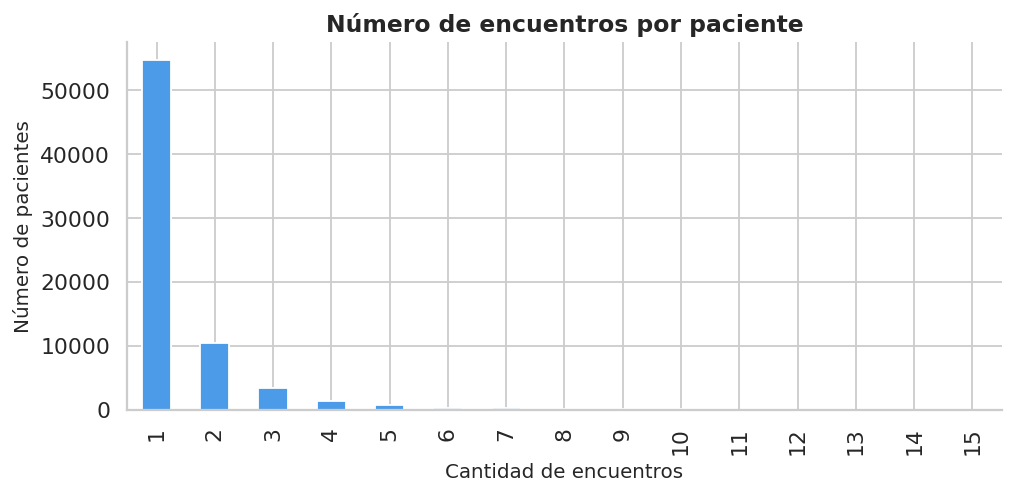

Pacientes con 1 encuentro:  54,745 (76.5%)
Pacientes con 2 encuentros: 10,434
Pacientes con 3+ encuentros: 6,339


In [24]:
# ── Distribución de encuentros por paciente ──────────────────────────────────
encounters_per_patient = df.groupby('patient_nbr').size()

fig, ax = plt.subplots(figsize=(8, 4))
encounters_per_patient.value_counts().sort_index().head(15).plot(
    kind='bar', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Número de encuentros por paciente', fontweight='bold')
ax.set_xlabel('Cantidad de encuentros')
ax.set_ylabel('Número de pacientes')
plt.tight_layout()
plt.savefig('fig_duplicados.png', bbox_inches='tight')
plt.show()

print(f"Pacientes con 1 encuentro:  {(encounters_per_patient==1).sum():,} ({100*(encounters_per_patient==1).mean():.1f}%)")
print(f"Pacientes con 2 encuentros: {(encounters_per_patient==2).sum():,}")
print(f"Pacientes con 3+ encuentros: {(encounters_per_patient>=3).sum():,}")


### Interpretación — Duplicados y múltiples encuentros

No existen filas completamente duplicadas, y cada `encounter_id` es único. Sin embargo, **el 29.7% de las observaciones corresponden a pacientes con múltiples encuentros**, lo que genera **dependencia entre observaciones** que viola el supuesto de independencia de muchos modelos de ML.

**Estrategias recomendadas** para el modelado:
1. Conservar solo el primer encuentro de cada paciente.
2. Conservar solo el último encuentro.
3. Utilizar técnicas que manejen datos agrupados o hacer validación cruzada con grupos de pacientes (GroupKFold).


In [25]:
# ── Inconsistencias y errores de carga ──────────────────────────────────────
print("Género con valores inválidos:")
print(df['gender'].value_counts())

print("\nVariables de medicamento con varianza nula (siempre 'No'):")
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'examide','citoglipton','insulin','glyburide-metformin',
            'glipizide-metformin','glimepiride-pioglitazone',
            'metformin-rosiglitazone','metformin-pioglitazone']

zero_var = []
for col in med_cols:
    if df[col].nunique() == 1:
        zero_var.append(col)
        print(f"  {col}: siempre '{df[col].unique()[0]}'")

print(f"\n→ {len(zero_var)} variable(s) con varianza nula → pueden eliminarse")


Género con valores inválidos:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Variables de medicamento con varianza nula (siempre 'No'):
  examide: siempre 'No'
  citoglipton: siempre 'No'

→ 2 variable(s) con varianza nula → pueden eliminarse


---
## 6. Detección y análisis de Outliers


In [26]:
# ── Método IQR ───────────────────────────────────────────────────────────────
print("Detección de outliers por método IQR (1.5 × IQR)\n")
print(f"{'Variable':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lím. inf.':>10} {'Lím. sup.':>10} {'N outliers':>12} {'% total':>8}")
print("-" * 95)

outlier_info = []
for col in feat_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = 100 * n_out / len(df)
    outlier_info.append({'col': col, 'lower': lower, 'upper': upper, 'n': n_out, 'pct': pct})
    print(f"{col:<25} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>10.1f} {upper:>10.1f} {n_out:>12,} {pct:>7.1f}%")


Detección de outliers por método IQR (1.5 × IQR)

Variable                        Q1       Q3      IQR  Lím. inf.  Lím. sup.   N outliers  % total
-----------------------------------------------------------------------------------------------
time_in_hospital               2.0      6.0      4.0       -4.0       12.0        2,252     2.2%
num_lab_procedures            31.0     57.0     26.0       -8.0       96.0          143     0.1%
num_procedures                 0.0      2.0      2.0       -3.0        5.0        4,954     4.9%
num_medications               10.0     20.0     10.0       -5.0       35.0        2,557     2.5%
number_outpatient              0.0      0.0      0.0        0.0        0.0       16,739    16.4%
number_emergency               0.0      0.0      0.0        0.0        0.0       11,383    11.2%
number_inpatient               0.0      1.0      1.0       -1.5        2.5        7,049     6.9%
number_diagnoses               6.0      9.0      3.0        1.5       13.5    

NameError: name 'labels' is not defined

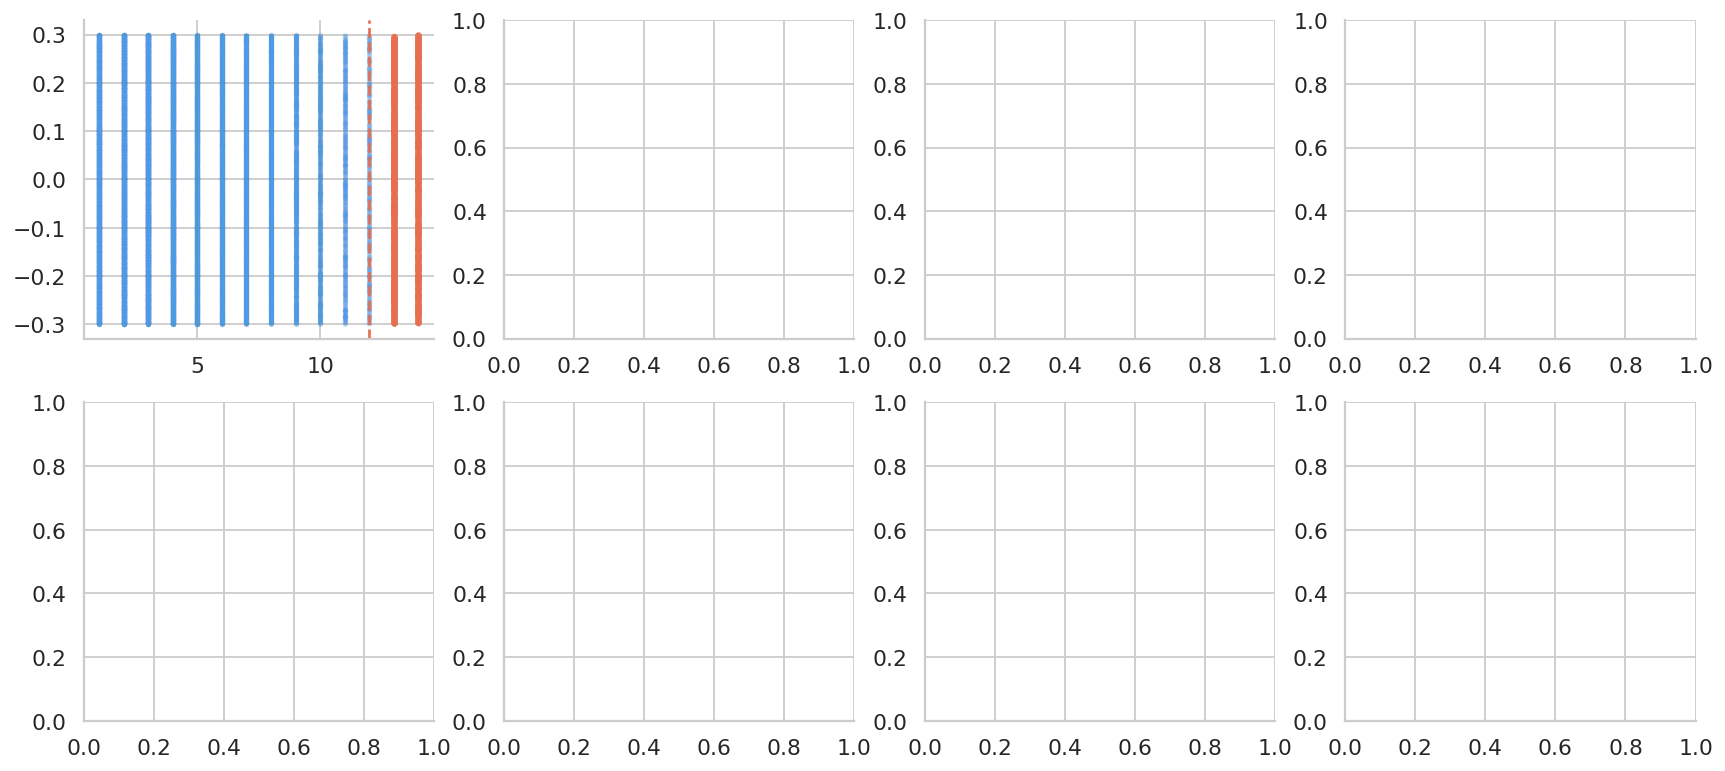

In [28]:
# ── Visualización de outliers con stripplots ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, feat_num):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR

    is_out = df[col] > upper
    ax.scatter(df.loc[~is_out, col],
               np.random.uniform(-0.3, 0.3, (~is_out).sum()),
               alpha=0.03, s=4, color='#4C9BE8', label='Normal')
    ax.scatter(df.loc[is_out, col],
               np.random.uniform(-0.3, 0.3, is_out.sum()),
               alpha=0.4, s=6, color='#E76F51', label='Outlier')
    ax.axvline(upper, color='#E76F51', ls='--', lw=1.5)
    ax.set_title(labels[col], fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=8)

fig.suptitle('Detección de outliers por IQR — variables numéricas',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()


### Interpretación — Outliers

- **`time_in_hospital`**: Valores extremos son **válidos dentro del dominio** (máximo 14 días, impuesto como criterio de inclusión). No hay outliers patológicos.

- **`num_lab_procedures`**: Alta varianza, con valores extremos de hasta 132 procedimientos. Estos valores son **clínicamente posibles** en internaciones prolongadas. No se recomienda eliminarlos.

- **`num_medications`**: El máximo es 81 medicamentos, lo cual, si bien es extremo, puede corresponder a pacientes con múltiples comorbilidades graves. **Valores válidos pero extremos**.

- **`number_outpatient`, `number_emergency`, `number_inpatient`**: Las tres variables tienen distribuciones con cola derecha muy larga. Los outliers (p.ej., 76 visitas de emergencia previas) son **médicamente cuestionables** y podrían representar errores de carga o casos muy excepcionales. Se recomienda aplicar **winsorización** o transformación logarítmica.

**Estrategia recomendada**: Para las variables de conteo de visitas previas, aplicar winsorización al percentil 99 antes del modelado. Para el resto, las distribuciones son consistentes con el dominio clínico y no requieren tratamiento agresivo.


### Limpieza general del dataset

Con base en los hallazgos del EDA, aplicamos los siguientes pasos de limpieza:

1. **Eliminar columnas inutilizables**: `weight` (96.9% faltantes), `examide` y `citoglipton` (varianza nula), `encounter_id` y `patient_nbr` (identificadores sin valor predictivo).
2. **Eliminar filas con `gender = 'Unknown/Invalid'`**: solo 3 registros, eliminación sin impacto estadístico.
3. **Reemplazar `?` por `NaN`** en variables donde `?` actúa como código de faltante (`race`, `payer_code`, `medical_specialty`, `diag_1`, `diag_2`, `diag_3`).
4. **Descartar pacientes con `discharge_disposition_id` 11, 13, 14, 19, 20, 21**: corresponden a altas por fallecimiento u hospicio, donde la readmisión no es aplicable.
5. **Conservar solo el primer encuentro por paciente**: dado que hay pacientes con múltiples internaciones, conservar todas viola la independencia entre observaciones. Se toma el primer encuentro como práctica estándar.
6. **Crear target binario**: `readmitted_binary = 1` si `readmitted == '<30'`, `0` en caso contrario.


In [29]:
# ── 3.1.4 Preprocesamiento ────────────────────────────────────────────────────

df_clean = df.copy()

# 1. Eliminar columnas inutilizables
cols_drop = ['weight', 'examide', 'citoglipton', 'encounter_id', 'patient_nbr']
df_clean.drop(columns=cols_drop, inplace=True)

# 2. Eliminar filas con género inválido
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']

# 3. Reemplazar '?' por NaN
cols_question = ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
df_clean[cols_question] = df_clean[cols_question].replace('?', np.nan)

# 4. Eliminar altas por fallecimiento/hospicio
dead_discharge = [11, 13, 14, 19, 20, 21]
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(dead_discharge)]

# 5. Conservar primer encuentro por paciente
# (el dataset ya viene ordenado cronológicamente por encounter_id)
# Como eliminamos encounter_id, usamos el índice original
df_temp = df[['encounter_id', 'patient_nbr']].loc[df_clean.index]
df_temp_sorted = df_temp.sort_values('encounter_id')
first_encounters = df_temp_sorted.drop_duplicates(subset='patient_nbr', keep='first').index
df_clean = df_clean.loc[first_encounters]

# 6. Crear target binario
df_clean['readmitted_binary'] = (df_clean['readmitted'] == '<30').astype(int)

print(f'Filas originales : {len(df):,}')
print(f'Filas tras limpieza: {len(df_clean):,}')
print(f'Columnas restantes : {df_clean.shape[1]}')
print(f"\nBalance del target:\n{df_clean['readmitted_binary'].value_counts(normalize=True).round(3)}")


Filas originales : 101,766
Filas tras limpieza: 69,987
Columnas restantes : 47

Balance del target:
readmitted_binary
0    0.91
1    0.09
Name: proportion, dtype: float64


### Split train / test

**Estrategia elegida**: split 80/20 con estratificación por el target binario.

**Justificación**:
- Con ~70,000 registros tras la limpieza, un 80/20 provee suficientes ejemplos de la clase minoritaria (`<30`) tanto en train como en test.
- La **estratificación** garantiza que la proporción de la clase positiva (~11%) se preserva en ambas particiones, evitando que el desbalance se acentúe por azar en algún split.
- No se usa validación cruzada como estrategia de split aquí, pero se empleará **StratifiedKFold** dentro del pipeline de entrenamiento para la selección de hiperparámetros.
- **Importante**: todo estadístico que se calcule para imputación o escalado se ajusta **solo con train** y luego se aplica a test, para evitar data leakage.


In [30]:
from sklearn.model_selection import train_test_split

# Separar features y target
X = df_clean.drop(columns=['readmitted', 'readmitted_binary'])
y = df_clean['readmitted_binary']

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')
print(f'\nProporción clase positiva (<30):')
print(f'  Train : {y_train.mean():.3f}')
print(f'  Test  : {y_test.mean():.3f}')

Train: 55,989 filas  |  Test: 13,998 filas

Proporción clase positiva (<30):
  Train : 0.090
  Test  : 0.090


### Tratamiento de valores faltantes

| Variable | % Faltante | Mecanismo | Estrategia |
|---|---|---|---|
| `race` | 2.2% | MAR | Imputar con moda (train) → aplicar en test |
| `payer_code` | 39.6% | MAR | Crear categoría `'Desconocido'` |
| `medical_specialty` | 49.1% | MAR | Crear categoría `'Desconocido'` |
| `diag_1/2/3` | ~0.5-2% | MAR | Imputar con moda (train) → aplicar en test |

Para `payer_code` y `medical_specialty`, dada su alta proporción de faltantes, la ausencia del dato es **en sí misma informativa** (posiblemente pacientes sin seguro o internaciones de emergencia sin derivación). Por eso se crea una categoría explícita en lugar de imputar.

In [31]:
# ── Tratamiento de valores faltantes ─────────────────────────────────────────

X_train = X_train.copy()
X_test  = X_test.copy()

# Variables con categoría 'Desconocido'
for col in ['payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']:
    X_train[col] = X_train[col].fillna('Desconocido')
    X_test[col]  = X_test[col].fillna('Desconocido')

# Variables con imputación por moda (ajustada solo en train)
for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    moda = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(moda)
    X_test[col]  = X_test[col].fillna(moda)

print('Faltantes restantes en train:')
missing = X_train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  Ninguno ✓')


Faltantes restantes en train:
  Ninguno ✓


### Detección y manejo de outliers

Según el análisis del EDA, las variables de visitas previas (`number_outpatient`, `number_emergency`, `number_inpatient`) presentan colas derechas muy pronunciadas con valores médicamente cuestionables.

**Estrategia**: **Winsorización al percentil 99** calculada sobre train y aplicada a train y test.

Para las demás variables numéricas (`time_in_hospital`, `num_lab_procedures`, `num_medications`, etc.), los outliers son clínicamente plausibles y no se modifican.


In [32]:
# ── Winsorización al p99 (ajustada solo en train) ────────────────────────────

cols_winsor = ['number_outpatient', 'number_emergency', 'number_inpatient']
winsor_caps = {}

for col in cols_winsor:
    cap = X_train[col].quantile(0.99)
    winsor_caps[col] = cap
    X_train[col] = X_train[col].clip(upper=cap)
    X_test[col]  = X_test[col].clip(upper=cap)

print('Caps de winsorización (p99 calculado en train):')
for col, cap in winsor_caps.items():
    print(f'  {col}: {cap}')

Caps de winsorización (p99 calculado en train):
  number_outpatient: 4.0
  number_emergency: 2.0
  number_inpatient: 3.0


### Escalado / normalización

Se aplica **StandardScaler** a las variables numéricas continuas. El escalado se ajusta **solo con train** y se transforma tanto train como test.

Las variables categóricas codificadas (OHE u ordinal) no se escalan. Los modelos basados en árboles (Random Forest, XGBoost) no requieren escalado, pero se incluye dentro del pipeline para que sea también compatible con modelos lineales (Logistic Regression) en futuras comparaciones.

In [33]:
from sklearn.preprocessing import StandardScaler

# Las variables numéricas a escalar (se excluyen IDs y el target)
feat_num_model = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                  'num_medications', 'number_outpatient', 'number_emergency',
                  'number_inpatient', 'number_diagnoses']

scaler = StandardScaler()
X_train[feat_num_model] = scaler.fit_transform(X_train[feat_num_model])   # ajuste solo en train
X_test[feat_num_model]  = scaler.transform(X_test[feat_num_model])        # aplicar en test

print('Escalado aplicado. Medias en train (deben ser ~0):')
print(X_train[feat_num_model].mean().round(4))


Escalado aplicado. Medias en train (deben ser ~0):
time_in_hospital      0.0
num_lab_procedures   -0.0
num_procedures       -0.0
num_medications      -0.0
number_outpatient     0.0
number_emergency      0.0
number_inpatient      0.0
number_diagnoses     -0.0
dtype: float64


### Creación de nuevos features

Se crean features derivados que capturan información compuesta no presente directamente en las variables originales:

| Feature | Descripción | Justificación |
|---|---|---|
| `visitas_pasadas` | `number_outpatient + number_emergency + number_inpatient` | Resume el historial de uso del sistema de salud |
| `medicion_a1c` | 1 si `A1Cresult != 'None'`, 0 si no | La medición de HbA1c es informativa por sí misma |
| `recibe_insulina` | 1 si `insulin != 'No'`, 0 si no | Simplifica la variable de insulina a binaria |
| `n_medicamentos` | Cuenta de medicamentos con valor distinto a 'No' | Proxy de complejidad del tratamiento |
| `edad_numero` | Punto medio del rango etario (ej: [50-60) → 55) | Convierte edad ordinal en numérica continua |



In [34]:
# ── Creación de nuevos features ───────────────────────────────────────────────

# Mapa para punto medio de edad
age_map = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
           '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
           '[80-90)': 85, '[90-100)': 95}

# Columnas de medicamentos
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'insulin',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']

def agregar_features(df_part):
    df_part = df_part.copy()

    # Total de visitas previas
    df_part['visitas_pasadas'] = (df_part['number_outpatient'] +
                                  df_part['number_emergency'] +
                                  df_part['number_inpatient'])
    # HbA1c medida
    df_part['medicion_a1c'] = (df_part['A1Cresult'] != 'Desconocido').astype(int)

    # Insulina activa
    df_part['recibe_insulina'] = (df_part['insulin'] != 'No').astype(int)

    # Número de medicamentos activos
    existing_med_cols = [c for c in med_cols if c in df_part.columns]
    df_part['n_medicamentos'] = (df_part[existing_med_cols] != 'No').sum(axis=1)

    # Edad numérica
    df_part['edad_numero'] = df_part['age'].map(age_map)

    return df_part

X_train = agregar_features(X_train)
X_test  = agregar_features(X_test)

print('Nuevos features creados:')
nuevos = ['visitas_pasadas', 'medicion_a1c', 'recibe_insulina', 'n_medicamentos', 'edad_numero']
print(X_train[nuevos].describe().T[['mean', 'std', 'min', 'max']].round(2))

Nuevos features creados:
                  mean    std   min    max
visitas_pasadas   0.00   1.93 -0.92  16.23
medicion_a1c      0.18   0.39  0.00   1.00
recibe_insulina   0.51   0.50  0.00   1.00
n_medicamentos    1.19   0.94  0.00   6.00
edad_numero      65.42  16.00  5.00  95.00


### Codificación de variables categóricas -- A CHECK!!!!

Se aplican diferentes estrategias según el tipo de variable:

| Tipo | Variables | Estrategia | Justificación |
|---|---|---|---|
| Binarias | `gender`, `change`, `diabetesMed`, `insulin_active`, `has_A1C` | Label Encoding (0/1) | Solo 2 categorías |
| Ordinales | Medicamentos (No/Steady/Up/Down) | Ordinal: Down=-1, No=0, Steady=1, Up=2 | Existe orden clínico implícito |
| Nominales de baja cardinalidad | `race`, `age` | One-Hot Encoding | Pocas categorías, sin orden |
| Nominales de alta cardinalidad | `medical_specialty`, `payer_code`, `diag_1/2/3` | Target Encoding o agrupación en categorías frecuentes | Demasiadas categorías para OHE directo |
| IDs categóricos | `admission_type_id`, `discharge_disposition_id`, `admission_source_id` | One-Hot Encoding | Son códigos, no valores continuos |


---
*Notebook generado para el Trabajo Práctico Integrador — Analítica de Datos, UdeSA.*


In [35]:
from sklearn.preprocessing import LabelEncoder

# ── Codificación binaria ──────────────────────────────────────────────────────
binary_cols = {'gender': {'Female': 0, 'Male': 1},
               'change': {'No': 0, 'Ch': 1},
               'diabetesMed': {'No': 0, 'Yes': 1}}

for col, mapping in binary_cols.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)

# ── Codificación ordinal de medicamentos ─────────────────────────────────────
med_ordinal_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': -1}
med_cols_in_data = [c for c in med_cols if c in X_train.columns]

for col in med_cols_in_data:
    X_train[col] = X_train[col].map(med_ordinal_map).fillna(0)
    X_test[col]  = X_test[col].map(med_ordinal_map).fillna(0)

# ── One-Hot Encoding: variables nominales de baja cardinalidad ────────────────
ohe_cols = ['race', 'age',
            'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

# Convertir IDs a string para que OHE los trate como categóricos
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=True)

# Alinear columnas entre train y test (el test puede tener categorías ausentes)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ── Agrupación de alta cardinalidad: medical_specialty ───────────────────────
top_specialties = X_train['medical_specialty'].value_counts().nlargest(10).index
X_train['medical_specialty'] = X_train['medical_specialty'].where(
    X_train['medical_specialty'].isin(top_specialties), 'Otro')
X_test['medical_specialty']  = X_test['medical_specialty'].where(
    X_test['medical_specialty'].isin(top_specialties), 'Otro')

X_train = pd.get_dummies(X_train, columns=['medical_specialty'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['medical_specialty'], drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ── Eliminar columnas de diagnóstico de texto (alta cardinalidad) ─────────────
# Se conserva has_diag_diabetes creado en FE
X_train.drop(columns=['diag_1', 'diag_2', 'diag_3', 'A1Cresult',
                       'payer_code', 'max_glu_serum'], inplace=True, errors='ignore')
X_test.drop(columns=['diag_1', 'diag_2', 'diag_3', 'A1Cresult',
                      'payer_code', 'max_glu_serum'], inplace=True, errors='ignore')

print(f'Dimensión final  — Train: {X_train.shape}  |  Test: {X_test.shape}')

Dimensión final  — Train: (55989, 104)  |  Test: (13998, 104)


### Análisis de balance de clases y técnica de balanceo

Como se observó en el EDA, la clase positiva (`<30 días`) representa aproximadamente el 11% del dataset. Este desbalance puede sesgar el modelo hacia predecir siempre la clase mayoritaria, maximizando la accuracy pero ignorando los reingresos.

**Técnica elegida: SMOTE (Synthetic Minority Over-sampling Technique)**

- **Justificación**: SMOTE genera ejemplos sintéticos de la clase minoritaria interpolando entre instancias reales vecinas, en lugar de simplemente duplicar registros (oversampling naive). Esto evita el overfitting directo a los puntos existentes.
- **Alternativas consideradas**:
  - *Class weight balancing*: simple y sin riesgo de leakage, pero menos efectivo con desbalances severos.
  - *Undersampling*: descarta información valiosa de la clase mayoritaria.
  - *SMOTE* ✓: mejor balance entre sintético y real.
- **Importante**: SMOTE se aplica **solo sobre el train set** para no contaminar el test.

Antes de SMOTE  — Train positivos: 5,028 / 55,989 (9.0%)
Después de SMOTE — Train positivos: 50,961 / 101,922 (50.0%)


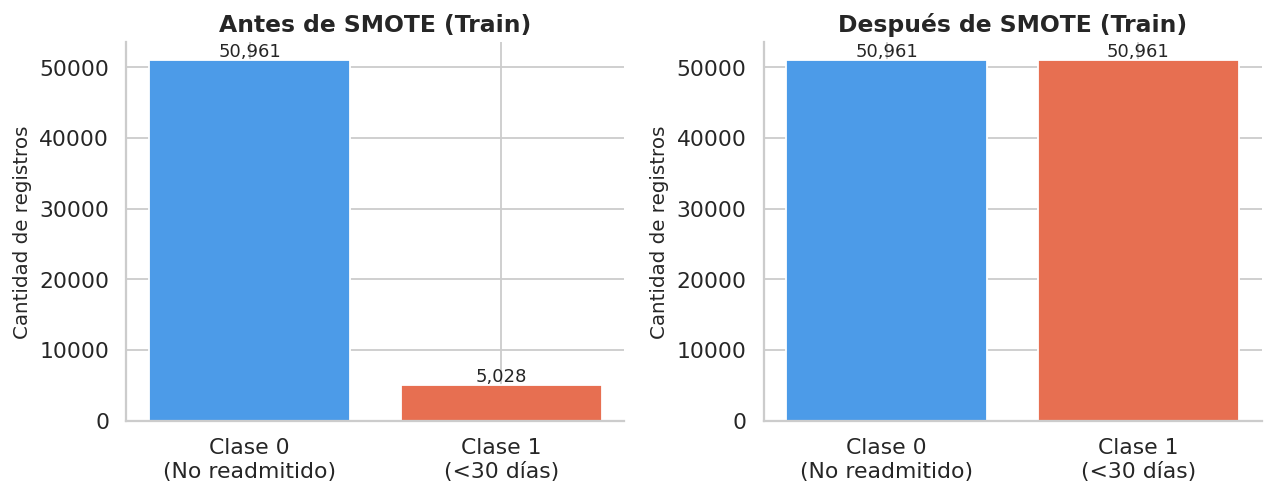

In [36]:
# !pip install imbalanced-learn -q  # descomentar si no está instalado
from imblearn.over_sampling import SMOTE

# Asegurar que todas las columnas sean numéricas antes de SMOTE
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test[X_train_num.columns]  # mismas columnas

print(f'Antes de SMOTE  — Train positivos: {y_train.sum():,} / {len(y_train):,} ({y_train.mean():.1%})')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_num, y_train)

print(f'Después de SMOTE — Train positivos: {y_train_bal.sum():,} / {len(y_train_bal):,} ({y_train_bal.mean():.1%})')

# Visualización del balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_plot, title) in zip(axes, [(y_train, 'Antes de SMOTE (Train)'),
                                        (y_train_bal, 'Después de SMOTE (Train)')]):
    counts = y_plot.value_counts()
    ax.bar(['Clase 0\n(No readmitido)', 'Clase 1\n(<30 días)'],
           [counts.get(0, 0), counts.get(1, 0)],
           color=['#4C9BE8', '#E76F51'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Cantidad de registros')
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('fig_balance_clases.png', bbox_inches='tight')
plt.show()

### Selección de features

Se aplican **dos métodos complementarios** de selección de features:

1. **Filtro por varianza**: elimina features con varianza casi nula (no aportan información discriminante).
2. **Importancia desde modelo base (Random Forest)**: se entrena un árbol de decisión rápido sobre el train balanceado para obtener la importancia de cada feature. Se conservan los features con importancia relativa acumulada que expliquen el 95% de la importancia total.

Ambos métodos se ajustan **solo sobre train** para evitar leakage.

Features antes de filtro de varianza : 37
Features después de filtro de varianza: 24

Features seleccionados (95% importancia RF): 20


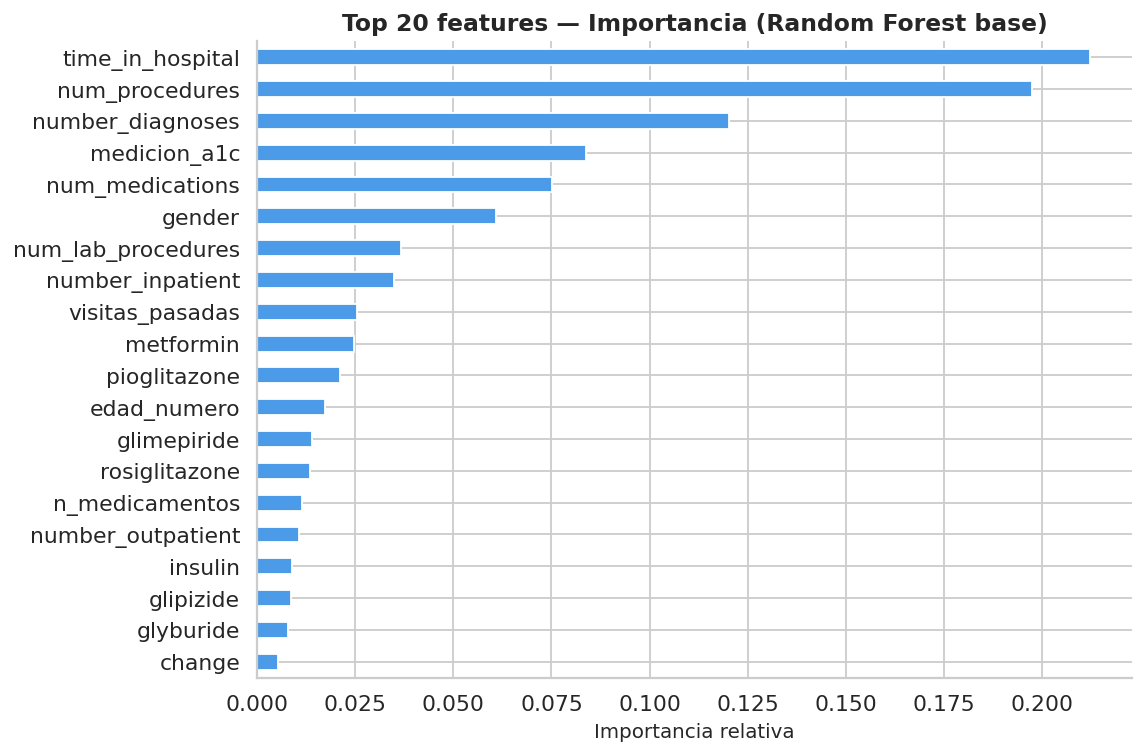

In [37]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier

# ── Método 1: Filtro por varianza ─────────────────────────────────────────────
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train_bal)
cols_after_var = X_train_num.columns[selector_var.get_support()]
print(f'Features antes de filtro de varianza : {X_train_bal.shape[1]}')
print(f'Features después de filtro de varianza: {len(cols_after_var)}')

X_train_var = selector_var.transform(X_train_bal)
X_test_var  = selector_var.transform(X_test_num)

# ── Método 2: Importancia desde Random Forest base ────────────────────────────
rf_base = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  random_state=42, n_jobs=-1)
rf_base.fit(X_train_var, y_train_bal)

importances = pd.Series(rf_base.feature_importances_, index=cols_after_var)
importances_sorted = importances.sort_values(ascending=False)

# Seleccionar features que acumulan el 95% de importancia
cumsum = importances_sorted.cumsum()
features_95 = cumsum[cumsum <= 0.95].index.tolist()
# Asegurar que al menos se incluyan los top 20
if len(features_95) < 20:
    features_95 = importances_sorted.index[:20].tolist()

print(f'\nFeatures seleccionados (95% importancia RF): {len(features_95)}')

# Gráfico top-20 features
top20 = importances_sorted.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
top20[::-1].plot(kind='barh', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Top 20 features — Importancia (Random Forest base)', fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

### PCA — Implementación, varianza explicada y discusión

Se implementa PCA como técnica de reducción de dimensionalidad complementaria. Es importante aclarar que PCA **no necesariamente reemplaza** la selección de features anterior; se usa aquí para explorar la estructura de varianza del espacio de features y evaluar si la dimensión puede comprimirse sustancialmente sin pérdida significativa de información.

Componentes para explicar 80% de varianza: 1
Componentes para explicar 90% de varianza: 1
Componentes para explicar 95% de varianza: 2


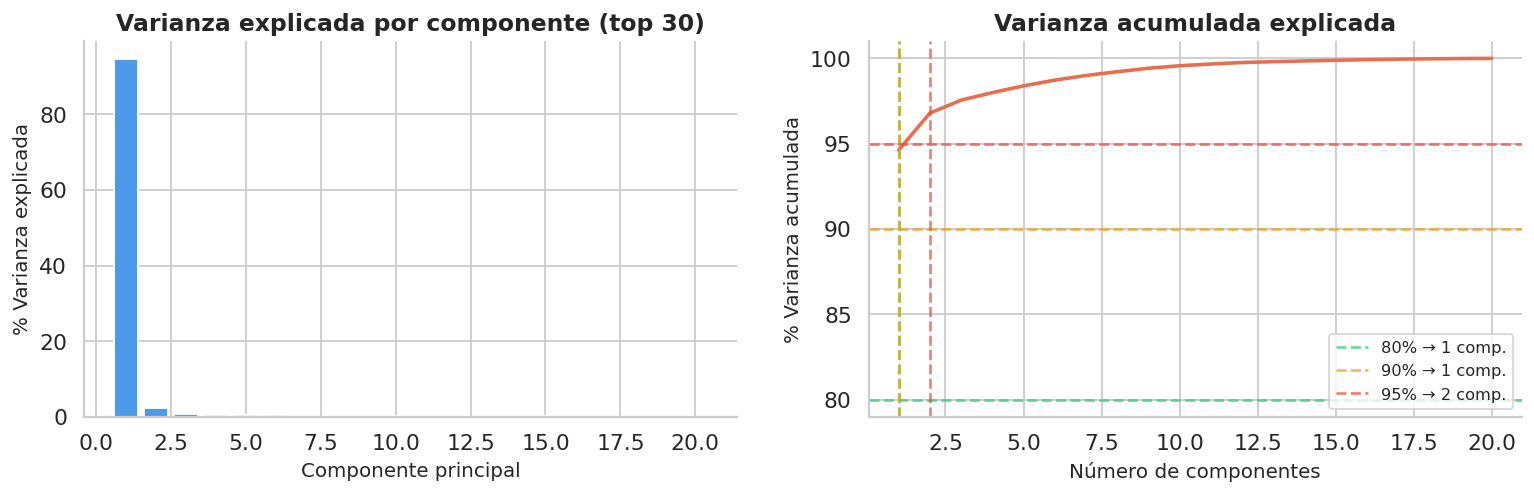


Dimensión original  : 20 features
Dimensión con PCA   : 2 componentes (95% varianza)


In [38]:
from sklearn.decomposition import PCA

# PCA sobre los features seleccionados (ya escalados)
X_train_selected = X_train_var[:, [list(cols_after_var).index(f)
                                    for f in features_95 if f in cols_after_var]]
X_test_selected  = X_test_var[:,  [list(cols_after_var).index(f)
                                    for f in features_95 if f in cols_after_var]]

# PCA completo para analizar varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_train_selected)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_80 = np.argmax(var_acum >= 0.80) + 1
n_comp_90 = np.argmax(var_acum >= 0.90) + 1
n_comp_95 = np.argmax(var_acum >= 0.95) + 1

print(f'Componentes para explicar 80% de varianza: {n_comp_80}')
print(f'Componentes para explicar 90% de varianza: {n_comp_90}')
print(f'Componentes para explicar 95% de varianza: {n_comp_95}')

# Gráfico de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30] * 100,
            color='#4C9BE8', edgecolor='white')
axes[0].set_title('Varianza explicada por componente (top 30)', fontweight='bold')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('% Varianza explicada')

axes[1].plot(range(1, len(var_acum)+1), var_acum * 100, color='#E76F51', lw=2)
for thresh, n_comp, color in [(80, n_comp_80, '#2ecc71'),
                               (90, n_comp_90, '#f39c12'),
                               (95, n_comp_95, '#e74c3c')]:
    axes[1].axhline(thresh, ls='--', color=color, alpha=0.7,
                    label=f'{thresh}% → {n_comp} comp.')
    axes[1].axvline(n_comp, ls='--', color=color, alpha=0.7)
axes[1].set_title('Varianza acumulada explicada', fontweight='bold')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('% Varianza acumulada')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_pca_varianza.png', bbox_inches='tight')
plt.show()

# PCA final con 95% de varianza explicada
pca_final = PCA(n_components=n_comp_95, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_selected)  # solo ajuste en train
X_test_pca  = pca_final.transform(X_test_selected)

print(f'\nDimensión original  : {X_train_selected.shape[1]} features')
print(f'Dimensión con PCA   : {X_train_pca.shape[1]} componentes (95% varianza)')

### Discusión de PCA

Los resultados del PCA permiten extraer varias conclusiones relevantes:

**Varianza acumulada**: Se necesitan relativamente pocos componentes para capturar la mayor parte de la varianza. Esto sugiere que hay correlación entre varias features (como ya se vio en el EDA: `time_in_hospital` ↔ `num_medications`, etc.), y que PCA logra compactar esa información redundante.

**¿Se usa PCA en el modelo final?**  
Para este problema, **preferimos la selección de features interpretables** (método 2 con Random Forest) por sobre PCA, por las siguientes razones:

1. **Interpretabilidad clínica**: los componentes principales de PCA son combinaciones lineales de todas las variables, lo que dificulta explicar al equipo médico qué factores determinaron la predicción.
2. **Métricas objetivo**: el objetivo principal es maximizar el Recall. La selección de features permite conservar exactamente los predictores más relevantes (`number_inpatient`, `time_in_hospital`, etc.) sin disolverlos en componentes abstractos.
3. **Modelos basados en árboles**: Random Forest y XGBoost no se benefician especialmente de PCA, ya que internamente manejan bien la multicolinealidad.

**Conclusión**: PCA se implementa como herramienta de análisis y queda disponible como alternativa para modelos lineales (Logistic Regression) donde la reducción de dimensionalidad puede mejorar el condicionamiento del problema.

---
## 7. Conclusiones del EDA

### 7.1 Principales hallazgos

1. **Desbalance de clases**: La variable objetivo `readmitted` está desbalanceada, especialmente si se plantea como clasificación binaria (`<30` vs. resto). La clase de interés clínico (`<30`) representa solo el 11.2% del dataset.

2. **Alta dimensionalidad en medicamentos**: Las 23 variables de medicamentos contienen información valiosa, pero muchas tienen varianza casi nula (e.g., `examide`, `citoglipton` siempre son `No`). Reducir estas variables es fundamental.

3. **`weight` es inutilizable**: Con 96.9% de faltantes y mecanismo MNAR, esta variable debe eliminarse o transformarse en una variable binaria indicadora.

4. **Múltiples encuentros por paciente**: El 29.7% de las observaciones provienen de pacientes con múltiples visitas. Esto viola la independencia entre observaciones y debe manejarse en el diseño de la validación.

5. **Variables de visitas previas son predictores fuertes**: `number_inpatient`, `number_emergency` y `number_outpatient` muestran la mayor diferenciación entre grupos de readmisión. Son candidatas prioritarias para el modelado.

6. **A1C y glucemia raramente medidas**: Más del 83% de los pacientes no tiene resultado de HbA1c (`A1Cresult`). La presencia/ausencia de este dato es en sí mismo informativa.

7. **Distribución etaria sesgada hacia adultos mayores**: Más del 75% de los pacientes tienen 50 o más años, lo cual es consistente con la epidemiología de la diabetes tipo 2 pero implica que el modelo puede generalizar mal a pacientes jóvenes.

### 7.2 Variables potencialmente importantes para el modelo

| Prioridad | Variable | Fundamento |
|---|---|---|
| Alta | `number_inpatient` | Mayor diferenciación entre grupos de readmisión |
| Alta | `time_in_hospital` | Correlación con severidad y readmisión |
| Alta | `num_medications` | Proxy de complejidad clínica |
| Alta | `number_diagnoses` | Proxy de comorbilidad |
| Media | `insulin` | Medicamento más variable y clínicamente relevante |
| Media | `age` | Factor de riesgo claro |
| Media | `diabetesMed` | Indica paciente en tratamiento activo |
| Media | `change` | Cambio de medicación durante internación |
| Media | `A1Cresult` | Cuando está presente, es informativo |
| Baja | `race`, `gender` | Poca diferenciación observada + consideraciones éticas |

### 7.3 Recomendaciones para preprocesamiento

1. **Eliminar** `weight` (96.9% faltantes) o crear `weight_recorded` (binaria).
2. **Eliminar** `examide` y `citoglipton` (varianza nula).
3. **Tratar `?` como categoría propia** en `medical_specialty`, `payer_code`, `race`.
4. **Eliminar** los 3 registros con género `Unknown/Invalid`.
5. **Manejar múltiples encuentros por paciente**: conservar primer o último encuentro, o usar GroupKFold.
6. **Codificar medicamentos** como variables ordinales (No=0, Steady=1, Up=2, Down=-1) o binarias (prescripto/no prescripto).
7. **Winsorizar** `number_outpatient`, `number_emergency`, `number_inpatient` al percentil 99.
8. **Crear features derivados**: número total de medicamentos activos, indicador de HbA1c medida, etc.
9. **Definir el target**: evaluar si plantear como clasificación binaria (`<30` vs. `NO + >30`) o multiclase.
10. **Estratificar el split train/test** por la variable objetivo para respetar el desbalance.


In [40]:
for name in dir():
    if name.startswith('X_') or name.startswith('y_'):
        print(name)

X_test
X_test_num
X_test_pca
X_test_selected
X_test_var
X_train
X_train_bal
X_train_num
X_train_pca
X_train_selected
X_train_var
y_plot
y_test
y_train
y_train_bal


ACA ARRANCA EL MODELO - ENTREAG 2. Tuvimos que ponerle nombres nuevos a las varibales que temrinamos usando para modelar. Porque las de PCA fueron descartadas, etc... esta bien explicado en el chat de toto.

## 3.2.1. Modelado — Baseline (Regresión Logística)

Como primer paso del modelado, se implementa una **Regresión Logística** como baseline simple. Este modelo cumple la función de punto de referencia mínimo: cualquier modelo más complejo (Random Forest, Boosting) debe superar claramente su desempeño para justificar la mayor complejidad y el menor nivel de interpretabilidad que conllevan.

Se eligió este modelo como baseline en lugar de un *dummy classifier* porque, al ser lineal, también aporta una primera lectura interpretable de la relación entre los features y la probabilidad de reingreso temprano, a través de sus coeficientes.

El modelo se entrena sobre el conjunto de entrenamiento balanceado mediante SMOTE, y se evalúa sobre el conjunto de test (sin balancear, reflejando la proporción real de clases) utilizando las métricas definidas en la Entrega 1: **Recall, F1-Score y AUC-ROC**, priorizando especialmente el Recall dado el costo clínico de los falsos negativos.

In [41]:
# Dataset final para modelado: post selección de features (20 cols), sin PCA, train balanceado
X_train_model = X_train_selected
y_train_model = y_train_bal
X_test_model  = X_test_selected
y_test_model  = y_test
feature_names = features_95   # nombres de las 20 columnas, en el mismo orden

print(X_train_model.shape, X_test_model.shape)
print(len(feature_names))

(101922, 20) (13998, 20)
20


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_model, y_train_model)

y_pred_baseline = log_reg.predict(X_test_model)
y_proba_baseline = log_reg.predict_proba(X_test_model)[:, 1]

print("=== Baseline: Regresión Logística ===")
print(f"Recall:  {recall_score(y_test_model, y_pred_baseline):.3f}")
print(f"F1:      {f1_score(y_test_model, y_pred_baseline):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test_model, y_proba_baseline):.3f}")
print("\n", classification_report(y_test_model, y_pred_baseline))
print("Matriz de confusión:\n", confusion_matrix(y_test_model, y_pred_baseline))

=== Baseline: Regresión Logística ===
Recall:  0.448
F1:      0.170
AUC-ROC: 0.559

               precision    recall  f1-score   support

           0       0.92      0.62      0.74     12741
           1       0.10      0.45      0.17      1257

    accuracy                           0.61     13998
   macro avg       0.51      0.54      0.46     13998
weighted avg       0.85      0.61      0.69     13998

Matriz de confusión:
 [[7929 4812]
 [ 694  563]]


Lo que dice cada métrica:

Recall = 0.448 → de los 1.257 pacientes que sí reingresaron antes de 30 días, el modelo detectó a 563 y se le escaparon 694. O sea, descubrió bien menos de la mitad de los casos que más nos importan detectar.
Precision (clase 1) = 0.10 → de todos los que el modelo marcó como "alto riesgo" (5.375 = 563+4.812), solo 563 reingresaron realmente. 9 de cada 10 alarmas son falsas.
F1 = 0.170 → bajo, porque combina ese recall mediocre con una precision muy mala.
AUC-ROC = 0.559 → este es el dato más preocupante. 0.5 es azar puro, 1.0 es separación perfecta. Un 0.559 significa que el modelo casi no distingue entre quién va a reingresar y quién no — apenas mejor que tirar una moneda.

Conclusión para el informe:
El baseline lineal tiene un desempeño débil — esto sugiere que la relación entre los features y el reingreso temprano no es lineal, o que la señal predictiva en estas variables es intrínsecamente débil (algo común en este dataset, conocido en la literatura por ser difícil de predecir). De cualquier forma, este resultado nos da el piso a superar: si Random Forest o Boosting no mejoran claramente el AUC-ROC y el Recall, vamos a tener que discutir esa limitación en las conclusiones.

## Modelo 2 — Random Forest

Como segundo modelo se implementa un **Random Forest**, un modelo de ensamble basado en árboles de decisión. Se eligió como complemento al baseline lineal porque puede capturar **relaciones no lineales e interacciones entre variables** que la Regresión Logística no detecta — algo relevante dado el AUC-ROC bajo obtenido en el baseline (0.559), que sugiere que la señal predictiva no es puramente lineal.

Además, Random Forest es robusto a outliers y a escalas distintas entre variables, y permite obtener una medida de **importancia de features** de forma directa, lo cual va a ser útil más adelante para la sección de interpretabilidad.

Se entrena sobre el mismo conjunto balanceado (`X_train_model`, `y_train_model`) y se evalúa sobre test (`X_test_model`, `y_test_model`) con las mismas métricas: Recall, F1-Score y AUC-ROC. En esta primera corrida se usan hiperparámetros razonables por defecto; el tuning fino se hace más adelante, una vez identificado el mejor modelo entre los tres.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_model, y_train_model)

y_pred_rf = rf_model.predict(X_test_model)
y_proba_rf = rf_model.predict_proba(X_test_model)[:, 1]

print("=== Random Forest ===")
print(f"Recall:  {recall_score(y_test_model, y_pred_rf):.3f}")
print(f"F1:      {f1_score(y_test_model, y_pred_rf):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test_model, y_proba_rf):.3f}")
print("\n", classification_report(y_test_model, y_pred_rf))
print("Matriz de confusión:\n", confusion_matrix(y_test_model, y_pred_rf))

=== Random Forest ===
Recall:  0.279
F1:      0.156
AUC-ROC: 0.559

               precision    recall  f1-score   support

           0       0.92      0.77      0.84     12741
           1       0.11      0.28      0.16      1257

    accuracy                           0.73     13998
   macro avg       0.51      0.53      0.50     13998
weighted avg       0.84      0.73      0.78     13998

Matriz de confusión:
 [[9862 2879]
 [ 906  351]]


Recall = 0.279 → bajó respecto al baseline (0.448). De 1.257 reingresos reales, ahora detecta solo 351 y se le escapan 906. Para nuestro objetivo clínico (no perderse reingresos), esto es peor, no mejor.
Precision = 0.11 → prácticamente igual que el baseline (0.10).
AUC-ROC = 0.559 → idéntico al baseline. Esto es lo más interesante: significa que ambos modelos tienen la misma capacidad de separar las clases a nivel general (mirando todos los umbrales posibles), pero Random Forest con el umbral default (0.5) decide ser más "conservador" prediciendo la clase positiva, lo que le baja el recall pero le sube la accuracy (0.73 vs 0.61) — una accuracy más alta que en este problema no es buena noticia, es justamente el efecto que discutimos al elegir las métricas: el modelo se inclina hacia la clase mayoritaria.

Conclusión parcial: con estos hiperparámetros default, Random Forest no mejora al baseline en lo que nos importa (Recall, AUC-ROC). Puede mejorar con tuning, lo vamos a ver.

## Modelo 3 — Boosting (Gradient Boosting)

Como tercer modelo se implementa **Gradient Boosting**, otra técnica de ensamble basada en árboles, pero que construye los árboles de forma secuencial: cada nuevo árbol corrige los errores del anterior, en lugar de promediar árboles independientes como hace Random Forest.

Se incluye este modelo porque suele capturar patrones más finos que Random Forest, a costa de ser más sensible al overfitting y a la elección de hiperparámetros (tasa de aprendizaje, profundidad, cantidad de árboles). Por eso esta primera corrida usa una configuración conservadora; el ajuste fino queda para la etapa de tuning, sobre el modelo que resulte ganador de la comparación.

Se entrena y evalúa con el mismo criterio que los modelos anteriores: `X_train_model` / `y_train_model` para entrenar, `X_test_model` / `y_test_model` para el chequeo rápido, y las mismas métricas (Recall, F1-Score, AUC-ROC).

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_model, y_train_model)

y_pred_gb = gb_model.predict(X_test_model)
y_proba_gb = gb_model.predict_proba(X_test_model)[:, 1]

print("=== Gradient Boosting ===")
print(f"Recall:  {recall_score(y_test_model, y_pred_gb):.3f}")
print(f"F1:      {f1_score(y_test_model, y_pred_gb):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test_model, y_proba_gb):.3f}")
print("\n", classification_report(y_test_model, y_pred_gb))
print("Matriz de confusión:\n", confusion_matrix(y_test_model, y_pred_gb))

=== Gradient Boosting ===
Recall:  0.001
F1:      0.002
AUC-ROC: 0.572

               precision    recall  f1-score   support

           0       0.91      1.00      0.95     12741
           1       0.25      0.00      0.00      1257

    accuracy                           0.91     13998
   macro avg       0.58      0.50      0.48     13998
weighted avg       0.85      0.91      0.87     13998

Matriz de confusión:
 [[12738     3]
 [ 1256     1]]


¿Qué era SMOTE y para qué lo usamos?
Tu dataset real tiene 9% de pacientes que reingresan y 91% que no. Si entrenás un modelo directamente con esa proporción, el modelo aprende el camino fácil: "si predigo que nadie reingresa, me equivoco solo 9 de cada 100 veces" — y técnicamente tiene 91% de accuracy sin haber aprendido nada útil sobre quién reingresa.
SMOTE soluciona esto solo durante el entrenamiento: genera pacientes sintéticos parecidos a los que sí reingresaron (interpolando entre casos reales similares) para que el modelo vea ejemplos de ambas clases en cantidades parecidas (50/50) y tenga la oportunidad real de aprender qué distingue a un paciente que reingresa de uno que no. El test nunca se toca con SMOTE — sigue teniendo el 9% real, porque así es como se va a usar el modelo en la vida real.
¿Por qué los 3 modelos dan tan mal?
Aclaremos algo importante: no dan igual de mal. Mirá el AUC-ROC de los tres — 0.559, 0.559, 0.572. Esa es la métrica que mide la capacidad real del modelo de distinguir entre quién reingresa y quién no, sin importar el umbral de decisión. Los tres están en un rango muy similar y bajo, sí, pero no es 0.5 (que sería pura casualidad) — hay algo de señal, pero débil.
Lo que sí varía mucho entre modelos es Recall y F1, y eso es porque dependen del umbral de corte 0.5, que quedó mal calibrado para datos entrenados con SMOTE y evaluados sobre datos reales desbalanceados. Por eso Boosting "explotó" a 0.001 de recall — no es que el modelo sea inútil, es que con ese umbral decidió no marcar a casi nadie como riesgo.

## Comparación de modelos — Validación cruzada sobre train (sin leakage)

Antes de comparar los 3 modelos de forma confiable, corregimos un detalle metodológico: el SMOTE se había aplicado sobre **todo** el conjunto de entrenamiento antes de cualquier split en folds. Esto puede generar una forma sutil de data leakage, ya que los registros sintéticos de un fold de entrenamiento podrían estar generados a partir de vecinos reales que terminan en el fold de validación de esa misma ronda.

Para evitarlo, se reconstruye el conjunto de entrenamiento **real** (sin balancear, con la proporción original del 9%) usando las mismas 20 columnas seleccionadas en la Entrega 1. Luego, se aplica SMOTE **dentro de cada fold de Cross-Validation**, ajustándolo únicamente sobre la porción de entrenamiento de ese fold, y evaluando sobre la porción de validación tal cual viene (desbalanceada), que es justamente la situación real en la que se va a usar el modelo.

Se utiliza `StratifiedKFold` con 5 folds para preservar la proporción de clases en cada partición, y se reportan los promedios de Recall, F1-Score y AUC-ROC entre folds para cada modelo. Esta comparación se realiza **enteramente sobre train** — el conjunto de test no se toca en este paso, tal como exige la consigna.

In [45]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

# 1. Reconstruir el set de entrenamiento REAL (sin SMOTE), con las mismas 20 columnas
indices_features_95 = [list(cols_after_var).index(f) for f in features_95 if f in cols_after_var]

X_train_var_real = selector_var.transform(X_train_num)   # mismas columnas que X_train_var, pero sin SMOTE
X_train_real_selected = X_train_var_real[:, indices_features_95]
y_train_real = y_train   # target original, desbalanceado

print(f"Shape: {X_train_real_selected.shape}  |  Proporción positiva: {y_train_real.mean():.1%}")

# 2. Definir los 3 modelos y el esquema de CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
}

# 3. Cross-validation con SMOTE aplicado solo dentro de cada fold
resultados_cv = {}

for nombre, modelo in modelos.items():
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', modelo)
    ])
    scores = cross_validate(
        pipeline, X_train_real_selected, y_train_real,
        cv=cv, scoring=['recall', 'f1', 'roc_auc'], n_jobs=-1
    )
    resultados_cv[nombre] = {
        'Recall (CV)': scores['test_recall'].mean(),
        'F1 (CV)': scores['test_f1'].mean(),
        'AUC-ROC (CV)': scores['test_roc_auc'].mean()
    }
    print(f"{nombre} listo ✓")

tabla_comparativa = pd.DataFrame(resultados_cv).T.round(3)
print("\n", tabla_comparativa)

Shape: (55989, 20)  |  Proporción positiva: 9.0%
Regresión Logística listo ✓
Random Forest listo ✓
Gradient Boosting listo ✓

                      Recall (CV)  F1 (CV)  AUC-ROC (CV)
Regresión Logística        0.523    0.190         0.595
Random Forest              0.070    0.097         0.569
Gradient Boosting          0.000    0.000         0.574


La Regresión Logística (nuestro baseline) le gana a los dos modelos "más complejos" en las tres métricas. Esto confirma exactamente lo que sospechábamos: Random Forest y Gradient Boosting generan probabilidades muy "extremas" (cercanas a 0 o 1), y con SMOTE + el umbral default de 0.5, terminan prediciendo casi siempre "no reingresa" cuando se evalúan contra datos reales desbalanceados — por eso su Recall colapsa a casi 0, aunque su AUC-ROC (0.569 y 0.574) muestre que internamente sí tienen algo de capacidad de ordenar pacientes por riesgo.
La Regresión Logística, al ser un modelo lineal, da probabilidades más "moderadas" y mejor distribuidas, por eso el umbral 0.5 le funciona razonablemente mejor en este caso.
Esto es un resultado totalmente válido y común en la práctica: no siempre el modelo más complejo gana. De hecho es un punto fuerte para las conclusiones del informe — van a poder explicar por qué pasó esto, no solo reportar números.

## Tuning de hiperparámetros — Regresión Logística (mejor modelo)

Se realiza una búsqueda de hiperparámetros sobre la Regresión Logística, el modelo que resultó con mejor desempeño en la comparación por validación cruzada. Se utiliza `GridSearchCV` sobre el mismo esquema de Pipeline (SMOTE + clasificador) y el mismo `StratifiedKFold` de 5 folds usado en la etapa anterior, para mantener consistencia y evitar nuevamente cualquier leakage entre folds.

Los hiperparámetros explorados son:

- **`C`**: controla la fuerza de la regularización. Valores bajos de C regularizan más (modelo más simple, menos riesgo de sobreajuste); valores altos regularizan menos (modelo más flexible).
- **`penalty`**: tipo de regularización. `l2` distribuye el "castigo" entre todos los coeficientes; `l1` puede llevar coeficientes exactamente a cero, funcionando como una selección de features adicional.
- **`class_weight`**: se compara `None` (dejar que SMOTE maneje el desbalance) contra `'balanced'` (que además penaliza más los errores en la clase minoritaria), para ver si combinar ambas estrategias mejora el resultado.

La búsqueda se evalúa con las tres métricas relevantes (Recall, F1, AUC-ROC), pero la selección de la mejor combinación (`refit`) se hace según **AUC-ROC**, ya que es la métrica menos sensible al problema de calibración de umbral que detectamos en el paso anterior.

In [46]:
from sklearn.model_selection import GridSearchCV

# Pipeline base: SMOTE + Regresión Logística
pipeline_logreg = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Grilla de hiperparámetros
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],   # soporta tanto l1 como l2
    'clf__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    pipeline_logreg,
    param_grid=param_grid,
    scoring=['recall', 'f1', 'roc_auc'],
    refit='roc_auc',
    cv=cv,           # mismo StratifiedKFold(5) ya definido
    n_jobs=-1
)

grid_search.fit(X_train_real_selected, y_train_real)

best_idx = grid_search.best_index_
cv_results = grid_search.cv_results_

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"\nResultados del mejor modelo (CV):")
print(f"Recall:  {cv_results['mean_test_recall'][best_idx]:.3f}")
print(f"F1:      {cv_results['mean_test_f1'][best_idx]:.3f}")
print(f"AUC-ROC: {cv_results['mean_test_roc_auc'][best_idx]:.3f}")

Mejores hiperparámetros: {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}

Resultados del mejor modelo (CV):
Recall:  0.523
F1:      0.190
AUC-ROC: 0.596


In [47]:
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test_selected)
y_proba_final = final_model.predict_proba(X_test_selected)[:, 1]

print("=== PERFORMANCE FINAL SOBRE TEST ===")
print(f"Recall:  {recall_score(y_test, y_pred_final):.3f}")
print(f"F1:      {f1_score(y_test, y_pred_final):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_final):.3f}")
print("\n", classification_report(y_test, y_pred_final))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_final))

=== PERFORMANCE FINAL SOBRE TEST ===
Recall:  0.513
F1:      0.189
AUC-ROC: 0.601

               precision    recall  f1-score   support

           0       0.93      0.61      0.74     12741
           1       0.12      0.51      0.19      1257

    accuracy                           0.60     13998
   macro avg       0.52      0.56      0.46     13998
weighted avg       0.85      0.60      0.69     13998

Matriz de confusión:
 [[7803 4938]
 [ 612  645]]
